<h1>Live / offline difference, overlap: 90.0%</h1>

___

In [1]:
import sys
#sys.path.insert(0, '/mxn/home/reblex/.local/lib/python3.8/site-packages')
from ptypy import io

from ptypy.utils import imsave
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import re
import ptypy.utils as u
from ptypy.utils import rmphaseramp
from skimage.restoration import unwrap_phase
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift
import ipywidgets as widgets
from matplotlib.gridspec import GridSpec
import h5py
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import scipy
%matplotlib widget
plt.ion()

WARNING ptypy - Message Passaging for Python (mpi4py) not found.
    CPU-parallelization disabled.
    Install python-mpi4py via the package repositories or with `pip install --user mpi4py`


In [2]:
#just for checking if %matplotlib widget is working
plt.figure()
plt.plot([2,5,3,2,4])
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

#### ___
<h2>Load and process data</h2>

___

<h3>Load data</h3>

In [3]:
#offline
filenames1 = {'55': '/data/staff/nanomax/reblex/data-simulated-recons/Siemens-img/simulated_recons/from_simg_256px_Au-Si3N4_step10px_1e+10_poisTRUE_spiral_00/simg_startframe400__fpb25_aperture-pr-update_00/rec/rec_scan_000000_DM_pycuda_3000.ptyr'}
#live
filenames2 = {'55': '/data/staff/nanomax/reblex/data-simulated-recons/Siemens-img/simulated_recons/from_simg_256px_Au-Si3N4_step10px_1e+10_poisTRUE_spiral_00/simg_startframe1____fpb25_aperture-pr-update_00/rec/rec_scan_000000_DM_pycuda_4739.ptyr'}

filenames1 = {'55': '/data/staff/nanomax/reblex/data-simulated-recons/Siemens-img/simulated_recons/from_simg_256px_Au-Si3N4_step10px_1e+10_poisTRUE_spiral_00/simg_startframe400__fpb25_aperture-pr-update_00/dumps/dump_scan_000000_DM_pycuda_1840.ptyr'}
filenames2 = {'55': '/data/staff/nanomax/reblex/data-simulated-recons/Siemens-img/simulated_recons/from_simg_256px_Au-Si3N4_step10px_1e+10_poisTRUE_spiral_00/simg_startframe1____fpb25_aperture-pr-update_00/dumps/dump_scan_000000_DM_pycuda_1840.ptyr'}

scan = '55'
samplename = {'55': '_spiralstep10px_1e10_apert-pr-update'}
if scan not in samplename.keys():
    samplename[scan] = ''
    print('Obs! No sample name will be used when saving figures.')


fname1 = filenames1[scan]
#live
fname2 = filenames2[scan]

obj1 = io.h5read(fname1, 'content/obj/Sscan00G00/data')['content/obj/Sscan00G00/data'][0]
obj2 = io.h5read(fname2, 'content/obj/Sscan00G00/data')['content/obj/Sscan00G00/data'][0]
pr1 = io.h5read(fname1, 'content/probe/Sscan00G00/data')['content/probe/Sscan00G00/data'][0]
pr2 = io.h5read(fname2, 'content/probe/Sscan00G00/data')['content/probe/Sscan00G00/data'][0]

obj1_psize = io.h5read(fname1, 'content/obj/Sscan00G00/_psize')['content/obj/Sscan00G00/_psize'][0]
obj2_psize = io.h5read(fname2, 'content/obj/Sscan00G00/_psize')['content/obj/Sscan00G00/_psize'][0]
pr1_psize = io.h5read(fname1, 'content/probe/Sscan00G00/_psize')['content/probe/Sscan00G00/_psize'][0]

savefigs=False

<h3>Process data</h3>

In [4]:
# Get the fnames of files containing the diffraction patterns:
dfile1 = glob.glob(fname1.rsplit('/',2)[0] + '/data/*.ptyd')[0]
dfile2 = glob.glob(fname2.rsplit('/',2)[0] + '/data/*.ptyd')[0]

diffraction1 = io.h5read(dfile1, 'chunks/0/data')['chunks/0/data']
diffraction2 = io.h5read(dfile2, 'chunks/0/data')['chunks/0/data']
mean_photons1 = np.sum(diffraction1)/diffraction1.shape[0]
mean_photons2 = np.sum(diffraction2)/diffraction2.shape[0]

print(mean_photons1, mean_photons2)


"""Get average photons/diff. image from chunked ptyd files"""
with h5py.File(dfile1, 'r') as f:
    nrchunks = len(f['chunks'].keys())
    sumphotons = 0
    diffshape = f['chunks']['0']['data'][:].shape[-2:]
    for k in range(nrchunks):
        sumphotons += np.sum(f['chunks'][str(k)]['data'][:])
print('Average nr. of photons per diffraction pattern: ', np.sum(sumphotons)/315) # 315 = nr of diffraction patterns

7845550490.12 7845550490.12
Average nr. of photons per diffraction pattern:  7809161336.869842


In [5]:
obj1_abs = np.abs(obj1)
obj2_abs = np.abs(obj2)
obj1_abslog = np.log(obj1_abs)
obj2_abslog = np.log(obj2_abs)

obj1_phase = np.angle(obj1)
obj2_phase = np.angle(obj2)

# Remove phase ramp
def rampweight(ob, scale=3):
    weights = np.zeros(ob.shape)#np.zeros_like(ob)
    M, N = weights.shape
    #weights[M // scale:M - M // scale, N // scale:N - N // scale] = 1  # centered box
    weights[int(M // scale):int(M - M // scale), int(N // scale):int(N - N // scale)] = 1  # centered box
    # weights[0:M - M // scale, N // scale:N - N // scale] = 1  # centered pillar
    #weights = np.abs(weights-1)  # Uncomment for inverting
    # always exlude a tiny bit on the edge
    mask = np.ones_like(weights, dtype=bool)
    edge = 30
    mask[ M//edge:M - M//edge , N//edge:N - N//edge  ] = False
    weights[mask] = 0
    return weights
w1 = rampweight(obj1, scale=100)#100) #5) #np.abs(rampweight(obj1, scale=3)-1)
w2 = rampweight(obj2, scale=100)#100) #5) #np.abs(rampweight(obj2, scale=3)-1)
#w1[:,:w1.shape[1]//2]=0  # only use the weights on the right side
#w2[:,:w2.shape[1]//2]=0  # only use the weights on the right side
# w1 = np.ones_like(obj1)
# w2 = np.ones_like(obj2)
obj1_ramp, ramp1 = rmphaseramp(obj1, w1, return_phaseramp=True)#rampweight(obj1, scale=3)
obj2_ramp, ramp2 = rmphaseramp(obj2, w2, return_phaseramp=True)
obj1_phaseramp = np.angle(obj1_ramp)
obj2_phaseramp = np.angle(obj2_ramp)
obj1_phaseramp_unwrapped = unwrap_phase(obj1_phaseramp) # unwrap_phase must have real input & output
obj2_phaseramp_unwrapped = unwrap_phase(obj2_phaseramp)
# ############################################################################################## ??????
#angle_trunc = lambda a: (a + np.ceil(abs(a) / (2 * np.pi)) * 2 * np.pi + np.pi) % (np.pi * 2) - np.pi # sets an array of radians into the interval (-pi, pi)
# obj1_phaseramp_unwrapped = angle_trunc(unwrap_phase(obj1_phaseramp)) # unwrap_phase must have real input & output
# obj2_phaseramp_unwrapped = angle_trunc(unwrap_phase(obj2_phaseramp))
# ############################################################################################## ??????
# shift1, error, phasediff = phase_cross_correlation(unwrap_phase(obj1_phaseramp)[100:-100,100:-100], unwrap_phase(obj2_phaseramp)[100:-100,100:-100], upsample_factor=100)

# diff_phase = obj1_phase - obj2_phase # goodplt.figure()
# diff_abslog_od = obj1_abslog - obj2_abslog # optical density
# diff_phaseramp_unwrappedshift = shift(obj1_phaseramp_unwrapped, [0.0, -0.15]) - obj2_phaseramp_unwrapped
# diff_phaseramp_unwrappedshift_ramp = np.angle(rmphaseramp(  np.exp(1j*diff_phaseramp_unwrappedshift), rampweight(np.exp(1j*diff_phaseramp_unwrappedshift), scale=3)  ))

obj1_rmramp_abs = np.abs(obj1_ramp)
obj2_rmramp_abs = np.abs(obj2_ramp)
obj1_rmramp_abslog = np.log(obj1_rmramp_abs)
obj2_rmramp_abslog = np.log(obj2_rmramp_abs)
diff_rmramp_abslog = obj1_rmramp_abslog - obj2_rmramp_abslog

diff_abslog_od = obj1_abslog - obj2_abslog # optical density
diff_phase = obj1_phase - obj2_phase
diff_phaseramp = obj1_phaseramp - obj2_phaseramp
diff_phaseramp_unwrapped = obj1_phaseramp_unwrapped - obj2_phaseramp_unwrapped
diff_phaseramp_unwrapped_ramp = np.angle(rmphaseramp(  np.exp(1j*diff_phaseramp_unwrapped), rampweight(np.exp(1j*diff_phaseramp_unwrapped), scale=3)  ))

marg = 100#500#250
shift1, error, phasediff = phase_cross_correlation(obj1_phaseramp_unwrapped[marg:-marg,marg:-marg], obj2_phaseramp_unwrapped[marg:-marg,marg:-marg], upsample_factor=1000)
# Update some differences according to the calculated shift between the offline-live recons.
#shift_val = np.array([-0.010, 0.565]) # [0.005, 0.604]
#obj2_phaseramp_unwrapped = shift(obj2_phaseramp_unwrapped, shift_val)#, [-0.015,  0.0  ])
#diff_phaseramp_unwrapped = obj1_phaseramp_unwrapped - obj2_phaseramp_unwrapped
#diff_phaseramp_unwrapped_ramp = np.angle(rmphaseramp(  np.exp(1j*diff_phaseramp_unwrapped), rampweight(np.exp(1j*diff_phaseramp_unwrapped), scale=3)  ))


# O = A * e^(i * phi) = e^(a + i* phi)
# A = np.abs(O)  # amplitude
# a = np.log(A)  # optical density

___
<h2>Plot summorized data</h2>

___

In [6]:
plt.cla()
plt.clf()
fig1 = plt.figure(num='First', figsize=(13.5, 12.0),tight_layout={'pad': 0.0})
fig1.subplots_adjust(left=0.03, bottom=0.05, right=0.97, top=0.9, wspace=0.33, hspace=0.2)
plt.rcParams['figure.titlesize'] = 'large' # default: 'large'
plt.rcParams['axes.titlesize'] = 'small' # default: 'large'
plt.rcParams['xtick.labelsize'] = 'small' # default: 'medium'
plt.rcParams['ytick.labelsize'] = 'small' # default: 'medium'

ax = [None]*18
gs1 = GridSpec(5, 8)
ax[0] = fig1.add_subplot(gs1[0, 0:2])
ax[1] = fig1.add_subplot(gs1[0, 2:4])
ax[2] = fig1.add_subplot(gs1[0, 4:6])
ax[3] = fig1.add_subplot(gs1[0, 6:8])

gs2 = GridSpec(5, 8)
ax[4] = fig1.add_subplot(gs2[1, 0:2])
ax[5] = fig1.add_subplot(gs2[1, 2:4])
ax[6] = fig1.add_subplot(gs2[1, 4:6])
ax[7] = fig1.add_subplot(gs2[1, 6:8])

gs3 = GridSpec(5, 8)
ax[8] = fig1.add_subplot(gs3[2, 0:2])
ax[9] = fig1.add_subplot(gs3[2, 2:4])
ax[10] = fig1.add_subplot(gs3[2, 4:6])
ax[11] = fig1.add_subplot(gs3[2, 6:8])

gs4 = GridSpec(5, 8)
ax[12] = fig1.add_subplot(gs4[3, 0:2])
ax[13] = fig1.add_subplot(gs4[3, 2:4])
ax[14] = fig1.add_subplot(gs4[3, 4:6])
ax[15] = fig1.add_subplot(gs4[3, 6:8])

gs5 = GridSpec(5, 8)
ax[16] = fig1.add_subplot(gs5[4, 0:2])
ax[17] = fig1.add_subplot(gs5[4, 2:4])
#ax[18] = fig1.add_subplot(gs5[4, 6:8])

im = [None]*18
im[0] = ax[0].imshow(obj1_abs, origin='lower')
im[1] = ax[1].imshow(obj2_abs, origin='lower')
im[2] = ax[2].imshow(obj1_abslog, origin='lower')
im[3] = ax[3].imshow(obj2_abslog, origin='lower')

im[4] = ax[4].imshow(obj1_phase, origin='lower') #
im[5] = ax[5].imshow(obj2_phase, origin='lower') #

im[6] = ax[6].imshow(np.abs(w1), origin='lower')
# im[6] = ax[6].imshow(np.abs(w1 + obj1_abs/5), origin='lower')  # Uncomment to show the object together with the weight
im[7] = ax[7].imshow(np.abs(w2), origin='lower')
# im[7] = ax[7].imshow(np.abs(w2 + obj2_abs/5), origin='lower')  # Uncomment to show the object together with the weight
im[8] = ax[8].imshow(np.angle(ramp1), origin='lower')
im[9] = ax[9].imshow(np.angle(ramp2), origin='lower')
im[10] = ax[10].imshow(obj1_phaseramp, origin='lower')
im[11] = ax[11].imshow(obj2_phaseramp, origin='lower')
im[12] = ax[12].imshow(obj1_phaseramp_unwrapped, origin='lower')
im[13] = ax[13].imshow(obj2_phaseramp_unwrapped, origin='lower')

im[14] = ax[14].imshow(np.log(np.abs(pr1)), origin='lower')
im[15] = ax[15].imshow(np.log(np.abs(pr2)), origin='lower')
im[16] = ax[16].imshow(np.angle(pr1), origin='lower')
im[17] = ax[17].imshow(np.angle(pr2), origin='lower')

for k in range(18):
    plt.colorbar(im[k], ax=ax[k], fraction=0.046, pad=0.04)

titles = ['obj1_abs', 'obj2_abs', 'obj1_abslog', 'obj2_abslog', 'obj1_phase', 'obj2_phase', 'w1', 'w2', 'np.angle(ramp1)', 'np.angle(ramp2)', 'obj1_phaseramp', 'obj2_phaseramp', 'obj1_phaseramp_unwrapped', 'obj2_phaseramp_unwrapped', 'log(abs(pr1))', 'log(abs(pr2))', 'np.angle(pr1)', 'np.angle(pr2)']


for n, title in enumerate(titles):
    plt.setp(ax[n], title=title)

def set_vminvmax(arr, std_factor):
    vmin = np.mean(arr[marg:-marg,marg:-marg]) - std_factor*np.std(arr[marg:-marg,marg:-marg])
    vmax = np.mean(arr[marg:-marg,marg:-marg]) + std_factor*np.std(arr[marg:-marg,marg:-marg])
    return vmin, vmax

# im[0].norm.vmin = 0.4
# im[0].norm.vmax = 0.6
# im[0].get_array()
for m in range(len(im)-4):
    im[m].set_clim(set_vminvmax(im[m].get_array().data, 1.0))

# im[0].set_clim(0.4, 0.6)
plt.show()



# lables = {'15': '_fpb50', '16': '_fpb20', '17': '_fpb300', '18': '_flip'}
# lable = lables[scan] if scan in lables.keys() else ''
# fig1.savefig(fname2.rsplit('/', 2)[0] + f'/data{lable}.png')

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [7]:
savefigs = False
if savefigs:
    lables = {'15': '_fpb50', '16': '_fpb20', '17': '_fpb300', '18': '_flip'}
    lable = lables[scan] if scan in lables.keys() else samplename[scan]
    fig1.savefig(fname2.rsplit('/', 2)[0] + f'/data{lable}.png')

___
<h2>Plot differences</h2>

___

<h4>Before shift correction</h4>

In [8]:
angle_trunc = lambda a: (a + np.ceil(abs(a) / (2 * np.pi)) * 2 * np.pi + np.pi) % (np.pi * 2) - np.pi # sets an array of radians into the interval (-pi, pi)

# obj2_phaseramp_unwrapped = shift(obj2_phaseramp_unwrapped, shift1)#[-0.0,  0.0  ])
# diff_phaseramp_unwrapped = obj1_phaseramp_unwrapped - obj2_phaseramp_unwrapped
# diff_phaseramp_unwrapped_ramp = np.angle(rmphaseramp(  np.exp(1j*diff_phaseramp_unwrapped), rampweight(np.exp(1j*diff_phaseramp_unwrapped), scale=3)  ))

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(3 * 5, 3))
fig.subplots_adjust(left=0.03, bottom=0.07, right=0.95, top=0.9, wspace=0.40, hspace=0.2)
subfig0 = axs[0].imshow(diff_rmramp_abslog, origin='lower')#norm=mpl.colors.LogNorm(vmin=2.27e-02))
subfig1 = axs[1].imshow(angle_trunc(diff_phase), origin='lower')
subfig2 = axs[2].imshow(angle_trunc(diff_phaseramp), origin='lower')
subfig3 = axs[3].imshow(angle_trunc(diff_phaseramp_unwrapped), origin='lower')
subfig4 = axs[4].imshow(angle_trunc(diff_phaseramp_unwrapped_ramp), origin='lower')
plt.colorbar(subfig0, ax=axs[0], fraction=0.046, pad=0.04)
plt.colorbar(subfig1, ax=axs[1], fraction=0.046, pad=0.04)
plt.colorbar(subfig2, ax=axs[2], fraction=0.046, pad=0.04)
plt.colorbar(subfig3, ax=axs[3], fraction=0.046, pad=0.04)
plt.colorbar(subfig4, ax=axs[4], fraction=0.046, pad=0.04)
plt.setp(axs[0], title='diff_rmramp_abslog')
plt.setp(axs[1], title='diff_phase')
plt.setp(axs[2], title='diff_phaseramp')
plt.setp(axs[3], title='diff_phaseramp_unwrapped')
plt.setp(axs[4], title='diff_phaseramp_unwrapped_ramp')

# Modified from https://github.com/matplotlib/matplotlib/issues/18563/
slider_values = {'0': [0.2, 1.2, 0.3, 4.0, 0.1], '1': [0.11, 0.8, 0.8, 1.1, 0.8], '2': [0.11, 1.2, 0.6, 1.5, 0.5], '3': [0.07, 0.8, 0.20, 1.2, 0.4], 
                '4': [0.11, 0.8, 0.8, 1.1, 0.8], '5': [0.11, 0.8, 0.8, 1.1, 0.8], '6': [0.11, 0.8, 0.8, 1.1, 0.8], '7': [0.11, 0.8, 0.8, 1.1, 0.8],
                '8': [1.0, 1.5, 1.8, 1.8, 1.8], '9': [0.11, 0.8, 0.8, 0.8, 0.8], '10': [0.11, 3.0, 2.0, 0.5, 0.5]}
if scan not in slider_values.keys():  # make sure there's an initial value for every scan-set.
    slider_values[scan] = [0.11, 0.8, 0.8, 1.1, 0.8]
    print(f"{''.center(80, '-')}\n{''.center(80, '-')}\n", f"UPDATE NEW ENTRANCE IN slider_values WITH KEY , '{scan}': [0.11, 0.8, 0.8, 1.1, 0.8]\n", f"{''.center(80, '-')}\n{''.center(80, '-')}\n")


def add_slider(arr, subfig, init_slider_value=1):
    slider = widgets.FloatSlider(value=init_slider_value, min=0.1, max=4.0, step=0.01)
    return slider, arr, subfig

def update(change):
    for k, (slider, arr, subfig) in enumerate(sliders):
        subfig.norm.vmin = np.mean(arr[marg:-marg,marg:-marg]) - slider.value*np.std(arr[marg:-marg,marg:-marg])
        subfig.norm.vmax = np.mean(arr[marg:-marg,marg:-marg]) + slider.value*np.std(arr[marg:-marg,marg:-marg])

sliders = []
for val, subfig in enumerate([subfig0, subfig1, subfig2, subfig3, subfig4]):
    slider, arr, subfig = add_slider(subfig.get_array().data, subfig, init_slider_value=slider_values[scan][val])
    sliders.append((slider, arr, subfig))
    slider.observe(update, names='value')

ui1 = widgets.HBox([slider for slider, _, _ in sliders])
display(ui1)

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
 UPDATE NEW ENTRANCE IN slider_values WITH KEY , '55': [0.11, 0.8, 0.8, 1.1, 0.8]
 --------------------------------------------------------------------------------
--------------------------------------------------------------------------------



<h4>After shift correction</h4>

In [9]:
shift_vals = {'0': np.array([-0.010, 0.565]), '1': shift1, '2': np.array([0., 0.210]), '3': np.array([0.020, 0.013]), 
                '4': shift1, '5': shift1, '6': shift1, '7': shift1, '8': np.array([ 0.34, -0.5]), '9': np.array([-0.4,  1.35]),
                '10': np.array([0.039, -0.33])} # array([ 0.34 , -0.157]) # 9: array([-0.009,  2.156])
if scan not in shift_vals.keys(): # make sure there's an shift value for every scan-set.
    shift_vals[scan] = shift1
    print(f"{''.center(80, '-')}\n{''.center(80, '-')}\n", f"UPDATE NEW ENTRANCE IN shift_vals WITH , '{scan}': np.array({[shift1[0], shift1[1]]})\n", f"{''.center(80, '-')}\n{''.center(80, '-')}\n")

shift_val = shift_vals[scan]

###############--> obj2_abslog_shift = shift(obj2_abslog, shift_val)#, [-0.015,  0.0  ])
obj2_rmramp_abslog_shift = shift(obj2_rmramp_abslog, shift_val)#, [-0.015,  0.0  ])
obj2_phase_shift = shift(obj2_phase, shift_val)#, [-0.015,  0.0  ])
obj2_phaseramp_shift = shift(obj2_phaseramp, shift_val)#, [-0.015,  0.0  ])
obj2_phaseramp_unwrapped_shift = shift(obj2_phaseramp_unwrapped, shift_val)#, [-0.015,  0.0  ])

###############--> diff_rmramp_abslog_shift = obj1_abslog - obj2_abslog_shift # optical density
diff_rmramp_abslog_shift = obj1_rmramp_abslog - obj2_rmramp_abslog_shift # optical density
diff_phase_shift = obj1_phase - obj2_phase_shift
diff_phaseramp_shift = obj1_phaseramp - obj2_phaseramp_shift
diff_phaseramp_unwrapped_shift = obj1_phaseramp_unwrapped - obj2_phaseramp_unwrapped_shift
diff_phaseramp_unwrapped_ramp_shift = np.angle(rmphaseramp(  np.exp(1j*diff_phaseramp_unwrapped_shift), rampweight(np.exp(1j*diff_phaseramp_unwrapped_shift), scale=3)  ))

fig3, axs = plt.subplots(nrows=1, ncols=5, figsize=(3 * 5, 3))
fig3.subplots_adjust(left=0.03, bottom=0.07, right=0.95, top=0.9, wspace=0.40, hspace=0.2)
subfig5 = axs[0].imshow(diff_rmramp_abslog_shift, origin='lower')#norm=mpl.colors.LogNorm(vmin=2.27e-02))
subfig6 = axs[1].imshow(angle_trunc(diff_phase_shift), origin='lower')
subfig7 = axs[2].imshow(angle_trunc(diff_phaseramp_shift), origin='lower')
subfig8 = axs[3].imshow(angle_trunc(diff_phaseramp_unwrapped_shift), origin='lower')
subfig9 = axs[4].imshow(angle_trunc(diff_phaseramp_unwrapped_ramp_shift), origin='lower')
plt.colorbar(subfig5, ax=axs[0], fraction=0.046, pad=0.04)
plt.colorbar(subfig6, ax=axs[1], fraction=0.046, pad=0.04)
plt.colorbar(subfig7, ax=axs[2], fraction=0.046, pad=0.04)
plt.colorbar(subfig8, ax=axs[3], fraction=0.046, pad=0.04)
plt.colorbar(subfig9, ax=axs[4], fraction=0.046, pad=0.04)
plt.setp(axs[0], title='diff_rmramp_abslog\n')
plt.setp(axs[1], title='diff_phase_shift\n')
plt.setp(axs[2], title='diff_phaseramp_shift\n')
plt.setp(axs[3], title='diff_phaseramp_unwrapped_shift\n')
plt.setp(axs[4], title='diff_phaseramp_unwrapped_ramp_shift\n')

sliders = []
for val, subfig in enumerate([subfig5, subfig6, subfig7, subfig8, subfig9]):
    slider, arr, subfig = add_slider(subfig.get_array().data, subfig, init_slider_value=slider_values[scan][val])
    sliders.append((slider, arr, subfig))
    slider.observe(update, names='value')

ui2 = widgets.HBox([slider for slider, _, _ in sliders])
display(ui2)
plt.show()

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
 UPDATE NEW ENTRANCE IN shift_vals WITH , '55': np.array([0.0, 0.0])
 --------------------------------------------------------------------------------
--------------------------------------------------------------------------------



Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [10]:
if savefigs == True:
    fig3.savefig(fname2.rsplit('/', 2)[0] + f'/offlinelivediff{samplename[scan]}.png')

<h3>True reference diff</h3>

In [9]:
# Load GT data.
"""
If the reconstructions are made on simulated data, compare the difference between the original probe and object.
"""
pr = None

if int(scan) in list(range(0,9)):
    print(scan,'no GT')
    fname3 = None
elif int(scan) in list(range(9,15)):
    fname3 = '/data/staff/nanomax/reblex/data-simulated-recons/NTT_scan_001190/original_recon/NTT_1190_startframe2912_crop1024_dist367_defocus980_a0.8_00/dumps/dump_scan_000000_DM_pycuda_1000.ptyr'
elif int(scan) in list(range(15,20)):
    fname3 = '/data/staff/nanomax/reblex/data-simulated-recons/NTT_scan_001190/original_recon/NTT_1190_startframe2912_crop256_dist367_defocus980_a0.8_00/dumps/dump_scan_000000_DM_pycuda_1000.ptyr'
elif int(scan) in list(range(20,27)):
    fname3 = '/data/staff/nanomax/reblex/data-simulated-recons/Siemens-img/41566_2016_Article_BFnphoton2015279_Fig1_HTML.png'
elif int(scan) in list(range(27,29)):
    fname3 = '/data/staff/nanomax/reblex/data-simulated-recons/Diamond/simulated_data/Diam_01/data/data_scan_000000.ptyd'#"/home/reblex/Documents/Diamond-Workshop-2023/small_data/painting.jpg"
elif int(scan) in list(range(29,50)):
    fname3 = '/data/staff/nanomax/reblex/data-simulated-recons/Siemens-img/siemens_array.npy'
    fname_pr = glob.glob(fname1.rsplit('/',2)[0] + '/data/*.ptyd')[0]
    pr = io.h5read(fname_pr, 'info/illumination/model')['info/illumination/model']
elif int(scan) in list(range(50,51)):
    fname3 = '/data/staff/nanomax/reblex/data-simulated-recons/Siemens-img/siemens_array.npy'
    fname_pr = '/data/staff/nanomax/reblex/data-simulated-recons/Siemens-img/simulated_data/simg_64px_Au-Si3N4_gauss_step10px_r40_1e+12_01/data/data_scan_000000.ptyd'
    pr = io.h5read(fname_pr, 'info/illumination/model')['info/illumination/model']
elif int(scan) in list(range(51,70)):
    fname3 = '/data/staff/nanomax/reblex/data-simulated-recons/Siemens-img/siemens_array.npy'
    fname_pr = '/data/staff/nanomax/reblex/data-simulated-recons/Siemens-img/simulated_data/simg_256px_Au-Si3N4_step10px_1e+12_00/data/data_scan_000000.ptyd'
    pr = io.h5read(fname_pr, 'info/illumination/model')['info/illumination/model']

if fname3 is not None:
    if fname3.endswith('.ptyr'):
        obj = io.h5read(fname3, 'content/obj/Sscan00G00/data')['content/obj/Sscan00G00/data'][0]
        pr = io.h5read(fname3, 'content/probe/Sscan00G00/data')['content/probe/Sscan00G00/data'][0]
    elif fname3.endswith('.ptyd'):
        obj = io.h5read(fname3, 'info/sample/model')['info/sample/model']
        fname_pr = '/data/staff/nanomax/reblex/data-simulated-recons/Diamond/dls_i08_nanogold_recon.ptyr'
        pr = io.h5read(fname_pr, 'content/probe/Sscan_00G00/data')['content/probe/Sscan_00G00/data'][0]
    elif fname3.endswith('.npy'):
        obj = np.load(fname3)
        #fname_pr = "/data/staff/nanomax/reblex/data-simulated-recons/NTT_scan_001190/original_recon/NTT_1190_startframe2912_crop256_dist367_defocus980_a0.8_00/dumps/dump_scan_000000_DM_pycuda_1000.ptyr"
        if pr is None:
            pr = io.h5read(fname_pr, 'content/probe/Sscan00G00/data')['content/probe/Sscan00G00/data'][0]
    else:
        from PIL import Image
        obj_arr = u.rgb2complex(np.array(Image.open(fname3)))
        obj = obj_arr*1e0
    obj_abs = np.abs(obj)
    obj_abslog = np.log(obj_abs)
    obj_phase = np.angle(obj)
    w = rampweight(obj, scale=100)
    obj_ramp, ramp = rmphaseramp(obj, w, return_phaseramp=True)
    obj_rmramp_abs = np.abs(obj_ramp)
    obj_rmramp_abslog = np.log(np.abs(obj_ramp))
    obj_phaseramp = np.angle(obj_ramp)
    obj_phaseramp_unwrapped = unwrap_phase(obj_phaseramp)


In [10]:
# Compare GT data with recons from simulations with DIFFERENT POSITIONS.

sh = obj_abs.shape
sh1 = obj1_abs.shape

if sh != sh1:
    # Also assuming that obj1_abs.shape == obj2_abs.shape here!
    
    padrow = (sh[0]-sh1[0])//2
    padcol = (sh[1]-sh1[1])//2
    # obj1_abs_pad = np.zeros(sh)    # old padding solution
    # obj1_abs_pad[ padrow:padrow+sh1[0], padcol:padcol+sh1[1] ] = obj1_abs    # old padding solution
    
    obj1_pad = np.pad(obj1, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj1_abs_pad = np.pad(obj1_abs, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj1_abslog_pad = np.pad(obj1_abslog, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj1_phase_pad = np.pad(obj1_phase, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj1_ramp_pad = np.pad(obj1_ramp, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj1_rmramp_abs_pad = np.pad(obj1_rmramp_abs, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj1_rmramp_abslog_pad = np.pad(obj1_rmramp_abslog, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj1_phaseramp_pad = np.pad(obj1_phaseramp, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    #obj1_phaseramp_pad = np.pad(obj1_phaseramp-(np.mean(obj1_phaseramp) -np.mean(obj_phaseramp)), ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj1_phaseramp_unwrapped_pad = np.pad(obj1_phaseramp_unwrapped, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))

    obj2_pad = np.pad(obj2, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj2_abs_pad = np.pad(obj2_abs, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj2_abslog_pad = np.pad(obj2_abslog, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj2_phase_pad = np.pad(obj2_phase, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj2_ramp_pad = np.pad(obj2_ramp, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj2_rmramp_abs_pad = np.pad(obj2_rmramp_abs, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj2_rmramp_abslog_pad = np.pad(obj2_rmramp_abslog, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj2_phaseramp_pad = np.pad(obj2_phaseramp, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    #obj2_phaseramp_pad = np.pad(obj2_phaseramp-(np.mean(obj2_phaseramp) -np.mean(obj_phaseramp)), ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    obj2_phaseramp_unwrapped_pad = np.pad(obj2_phaseramp_unwrapped, ((padrow,sh[0]-padrow-sh1[0]),(padcol,sh[1]-padcol-sh1[1])))
    
    marg = 220
    shift2offline, error, phasediff = phase_cross_correlation(obj_ramp[marg:-marg,marg:-marg], obj1_ramp_pad[marg:-marg,marg:-marg], upsample_factor=100)
    

    print(sh, sh1, obj1_phaseramp_unwrapped_pad.shape, shift2offline)

(1341, 1341) (446, 451) (1341, 1341) [0. 0.]


In [11]:
sh != sh1

True

In [12]:
# Compare GT data with recons.


marg = ((min(sh) - max(sh1)) // 2) + int(max(sh1) // 3.15)#3.8)

if sh != sh1:
    # Then we should use padded data obtained in the cell above!
    obj1_abs_ = obj1_abs_pad - np.mean(obj1_abs_pad[marg:-marg, marg:-marg])
    obj1_abslog_ = obj1_abslog_pad - np.mean(obj1_abslog_pad[marg:-marg, marg:-marg])
    obj1_phase_ = obj1_phase_pad - np.mean(obj1_phase_pad[marg:-marg, marg:-marg])
    obj1_ramp_ = obj1_ramp_pad - np.mean(obj1_ramp_pad[marg:-marg, marg:-marg])
    obj1_rmramp_abs_ = obj1_rmramp_abs_pad - np.mean(obj1_rmramp_abs_pad[marg:-marg, marg:-marg])
    obj1_rmramp_abslog_ = obj1_rmramp_abslog_pad - np.mean(obj1_rmramp_abslog_pad[marg:-marg, marg:-marg])
    obj1_phaseramp_ = obj1_phaseramp_pad - np.mean(obj1_phaseramp_pad[marg:-marg, marg:-marg])
    obj1_phaseramp_unwrapped_ = obj1_phaseramp_unwrapped_pad - np.mean(obj1_phaseramp_unwrapped_pad[marg:-marg, marg:-marg])

    obj2_abs_ = obj2_abs_pad - np.mean(obj2_abs_pad[marg:-marg, marg:-marg])
    obj2_abslog_ = obj2_abslog_pad - np.mean(obj2_abslog_pad[marg:-marg, marg:-marg])
    obj2_phase_ = obj2_phase_pad - np.mean(obj2_phase_pad[marg:-marg, marg:-marg])
    obj2_ramp_ = obj2_ramp_pad - np.mean(obj2_ramp_pad[marg:-marg, marg:-marg])
    obj2_rmramp_abs_ = obj2_rmramp_abs_pad - np.mean(obj2_rmramp_abs_pad[marg:-marg, marg:-marg])
    obj2_rmramp_abslog_ = obj2_rmramp_abslog_pad - np.mean(obj2_rmramp_abslog_pad[marg:-marg, marg:-marg])
    obj2_phaseramp_ = obj2_phaseramp_pad - np.mean(obj2_phaseramp_pad[marg:-marg, marg:-marg])
    obj2_phaseramp_unwrapped_ = obj2_phaseramp_unwrapped_pad - np.mean(obj2_phaseramp_unwrapped_pad[marg:-marg, marg:-marg])

obj_abs_ = obj_abs
obj_abslog_ = obj_abslog
obj_phase_ = obj_phase
obj_ramp_ = obj_ramp
obj_rmramp_abs_ = obj_rmramp_abs
obj_rmramp_abslog_ = obj_rmramp_abslog
obj_phaseramp_ = obj_phaseramp
obj_phaseramp_unwrapped_ = obj_phaseramp_unwrapped


shift2offline, error, phasediff1 = phase_cross_correlation(obj_ramp_, obj1_ramp_, upsample_factor=100)
shift2live, error, phasediff2 = phase_cross_correlation(obj_ramp_, obj2_ramp_, upsample_factor=100)

# best manual shifts: 15offline: np.array([2.038, -2.029])   - region differences
# 15live: np.array([2.037, -2.12]) - region differences
# 16live: np.array([1.34, -2.10])  - region differences
# 17live: np.array([2.02, -2.08])  - region differences
# 18live: np.array([1.77, -1.46])  - region differences

shift_vals1 = {'9': np.array([7.49, -8.5]), '10': np.array([4.00, -3.5]), '15': np.array([2.038, -2.029]), '16': np.array([2.038, -2.029]), '17': np.array([2.038, -2.029]), '18': np.array([2.038, -2.029])}  # 15: 2.013, -1.997
shift_vals2 = {'9':  np.array([7.776, -7.143]), '10': np.array([4.073, -3.982]), '15': np.array([2.037, -2.12]), '16': np.array([1.34, -2.10]), '17': np.array([2.02, -2.08]),
               '18': np.array([1.77, -1.46])}  # 2.013, -1.997, best by trial n err with angle_trunc: 1.995, -1.975
if scan not in shift_vals1.keys():  # make sure there's an shift value for every scan-set.
    shift_vals1[scan] = shift2offline
    shift_vals2[scan] = shift2live
    print(f"{''.center(80, '-')}\n{''.center(80, '-')}\n",
          f"UPDATE NEW ENTRANCE IN shift_vals WITH \nshift_vals1\t, '{scan}': np.array({[shift2offline[0], shift2offline[1]]})\nshift_vals2\t, '{scan}': np.array({[shift2live[0], shift2live[1]]})\n",
          f"{''.center(80, '-')}\n{''.center(80, '-')}\n")
else:
    shift2offline = shift_vals1[scan]
    shift2live = shift_vals2[scan]

if obj_rmramp_abslog_.shape != obj1_rmramp_abslog_.shape:
    print('Reconstructions have different shapes! Rebinning is made in order to calculate the difference, this might cause changes along the edges of the sample!')
    # Difference in offline recon
    diff1_rmramp_abslog_od = u.rebin_2d(obj_rmramp_abslog_[:3724, :3724], 2)[0] - obj1_rmramp_abslog_[:, :1862]  # optical density
    diff1_phase = u.rebin_2d(obj_phase_[:3724, :3724], 2)[0] - obj1_phase_[:, :1862]
    diff1_phaseramp = u.rebin_2d(obj_phaseramp_[:3724, :3724], 2)[0] - obj1_phaseramp_[:, :1862]
    diff1_phaseramp_unwrapped = u.rebin_2d(obj_phaseramp_unwrapped_[:3724, :3724], 2)[0] - obj1_phaseramp_unwrapped_[:, :1862]
    diff1_pr_phase = np.abs(u.rebin_2d(pr, 2)[0]) - np.abs(pr1)

    shift_offline = np.array([4.00, -3.5])  # 4.026, -3.672# 4.023, -3.611# 4.023, -3.5#4.00, -3.5 # 4.039, -3.673
    diff1_rmramp_abslog_od = u.rebin_2d(obj_rmramp_abslog_[:3724, :3724], 2)[0] - shift(obj1_rmramp_abslog_[:, :1862], shift_offline)
    diff1_phase = u.rebin_2d(obj_phase_[:3724, :3724], 2)[0] - shift(obj1_phase_[:, :1862], shift_offline)
    diff1_phaseramp = u.rebin_2d(obj_phaseramp_[:3724, :3724], 2)[0] - shift(obj1_phaseramp_[:, :1862], shift_offline)
    diff1_phaseramp_unwrapped = u.rebin_2d(obj_phaseramp_unwrapped_[:3724, :3724], 2)[0] - shift(obj1_phaseramp_unwrapped_[:, :1862], shift_offline)

    # Difference in live recon
    diff2_rmramp_abslog_od = u.rebin_2d(obj_rmramp_abslog_[:3724, :3724], 2)[0] - obj2_rmramp_abslog_[:, :1862]  # optical density
    diff2_phase = u.rebin_2d(obj_phase_[:3724, :3724], 2)[0] - obj2_phase_[:, :1862]
    diff2_phaseramp = u.rebin_2d(obj_phaseramp_[:3724, :3724], 2)[0] - obj2_phaseramp_[:, :1862]
    diff2_phaseramp_unwrapped = u.rebin_2d(obj_phaseramp_unwrapped_[:3724, :3724], 2)[0] - obj2_phaseramp_unwrapped_[:, :1862]
    diff2_pr_phase = np.abs(u.rebin_2d(pr, 2)[0]) - np.abs(pr2)

    shift_live = np.array([4.073, -3.982])  # 1.875, -4.835 # 4.0, -4.335
    diff2_rmramp_abslog_od = u.rebin_2d(obj_rmramp_abslog_[:3724, :3724], 2)[0] - shift(obj2_rmramp_abslog_[:, :1862], shift_live)
    diff2_phase = u.rebin_2d(obj_phase_[:3724, :3724], 2)[0] - shift(obj2_phase_[:, :1862], shift_live)
    diff2_phaseramp = u.rebin_2d(obj_phaseramp_[:3724, :3724], 2)[0] - shift(obj2_phaseramp_[:, :1862], shift_live)
    diff2_phaseramp_unwrapped = u.rebin_2d(obj_phaseramp_unwrapped_[:3724, :3724], 2)[0] - shift(obj2_phaseramp_unwrapped_[:, :1862], shift_live)
else:
    # # Difference in offline recon
    diff1_rmramp_abslog_od = obj_rmramp_abslog_ - shift(obj1_rmramp_abslog_, shift2offline) # optical density
    diff1_phase = obj_phase_ - shift(obj1_phase_, shift2offline)
    diff1_phaseramp = obj_phaseramp_ - shift(obj1_phaseramp_, shift2offline)
    diff1_phaseramp_unwrapped = obj_phaseramp_unwrapped_ - shift(obj1_phaseramp_unwrapped_, shift2offline)
    diff1_pr_abs = np.log(np.abs(pr)) - np.log(np.abs(pr1))
    diff1_pr_phase = np.angle(pr) - np.angle(pr1)
    diff1_phase[diff1_phase < np.pi] += 2*np.pi
    diff1_phase[diff1_phase > np.pi] -= 2*np.pi

    # Difference in live recon
    diff2_rmramp_abslog_od = obj_rmramp_abslog_ - shift(obj2_rmramp_abslog_, shift2live)  # optical density
    diff2_phase = obj_phase_ - shift(obj2_phase_, shift2live)
    diff2_phaseramp = obj_phaseramp_ - shift(obj2_phaseramp_, shift2live)
    diff2_phaseramp_unwrapped = obj_phaseramp_unwrapped_ - shift(obj2_phaseramp_unwrapped_, shift2live)
    diff2_pr_abs = np.abs(pr) - np.abs(pr2)
    diff2_pr_phase = np.angle(pr) - np.angle(pr2)
    diff2_phase[diff2_phase < np.pi] += 2*np.pi
    diff2_phase[diff2_phase > np.pi] -= 2*np.pi

fig4, axs = plt.subplots(nrows=1, ncols=4, figsize=(3 * 5, 3.5))
fig4.subplots_adjust(left=0.03, bottom=0.07, right=0.95, top=0.95, wspace=0.40, hspace=0.2)
##subfig10 = axs[0].imshow(diff1_rmramp_abslog_od, origin='lower', interpolation='None')#norm=mpl.colors.LogNorm(vmin=2.27e-02))
x1 = np.arange(0, (sh[1] + 1) * obj1_psize, obj1_psize)
y1 = np.arange(0, (sh[0] + 1) * obj1_psize, obj1_psize)
X, Y = np.meshgrid(x1, y1)
subfig10 = axs[0].pcolormesh(X, Y, diff1_rmramp_abslog_od)  # , origin='lower', interpolation='None')
axs[0].set_box_aspect(sh[0] / sh[1])
subfig11 = axs[1].imshow((diff1_phase), origin='lower', interpolation='None')
subfig12 = axs[2].imshow((diff1_phaseramp), origin='lower', interpolation='None')
subfig13 = axs[3].imshow((diff1_phaseramp_unwrapped), origin='lower', interpolation='None')
plt.colorbar(subfig10, ax=axs[0], fraction=0.046, pad=0.04)
plt.colorbar(subfig11, ax=axs[1], fraction=0.046, pad=0.04)
plt.colorbar(subfig12, ax=axs[2], fraction=0.046, pad=0.04)
plt.colorbar(subfig13, ax=axs[3], fraction=0.046, pad=0.04)
plt.setp(axs[0], title='diff1_rmramp_abslog')
plt.setp(axs[1], title='diff1_phase_shift')
plt.setp(axs[2], title='diff1_phaseramp_shift')
plt.setp(axs[3], title='diff1_phaseramp_unwrapped_shift')
fig4.suptitle(f'Offline difference, Shift: {shift2offline}')

fig5, axs = plt.subplots(nrows=1, ncols=4, figsize=(3 * 5, 3.5))
fig5.subplots_adjust(left=0.03, bottom=0.07, right=0.95, top=0.95, wspace=0.40, hspace=0.2)
subfig14 = axs[0].imshow(diff2_rmramp_abslog_od, origin='lower', interpolation='None')  # norm=mpl.colors.LogNorm(vmin=2.27e-02))
subfig15 = axs[1].imshow((diff2_phase), origin='lower', interpolation='None')
subfig16 = axs[2].imshow((diff2_phaseramp), origin='lower', interpolation='None')
subfig17 = axs[3].imshow((diff2_phaseramp_unwrapped), origin='lower', interpolation='None')
plt.colorbar(subfig14, ax=axs[0], fraction=0.046, pad=0.04)
plt.colorbar(subfig15, ax=axs[1], fraction=0.046, pad=0.04)
plt.colorbar(subfig16, ax=axs[2], fraction=0.046, pad=0.04)
plt.colorbar(subfig17, ax=axs[3], fraction=0.046, pad=0.04)
plt.setp(axs[0], title='diff2_rmramp_abslog')
plt.setp(axs[1], title='diff2_phase_shift')
plt.setp(axs[2], title='diff2_phaseramp_shift')
plt.setp(axs[3], title='diff2_phaseramp_unwrapped_shift')
fig5.suptitle(f'Live difference, Shift: {shift2live}')


slider_values = {'9':  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], '10': [1.0, 1.0, 0.3, 1.0, 1.0, 1.0, 0.3, 1.0], '11': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], '12': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
                 '13': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], '14': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], '15': [1.0, 1.0, 0.2, 1.8, 1.0, 1.0, 0.2, 1.8], '16': [1.0, 1.0, 0.2, 1.0, 1.0, 1.0, 1.0, 2.0],
                 '17': [1.0, 1.0, 0.2, 1.0, 1.0, 1.0, 0.25, 1.7], '18': [1.0, 1.0, 0.2, 1.8, 1.0, 1.0, 1.0, 1.8], '19': [1.0, 1.0, 0.2, 1.8, 1.0, 1.0, 0.2, 1.8], '20': [1.0, 1.0, 0.2, 1.8, 1.0, 1.0, 0.2, 1.8],
                 '29': [1.0, 1.0, 0.2, 1.8, 1.0, 1.0, 0.2, 1.8], '30': [1.0, 1.0, 0.2, 1.8, 1.0, 1.0, 0.2, 1.8]}
if scan not in slider_values.keys():  # make sure there's an shift value for every scan-set.
    slider_values[scan] = slider_values['30']

sliders = []
for val, subfig in enumerate([subfig10, subfig11, subfig12, subfig13, subfig14, subfig15, subfig16, subfig17]):  # subfig10, subfig11, subfig12, subfig13, subfig14, subfig15, subfig16, subfig17
    slider, arr, subfig = add_slider(subfig.get_array().data, subfig, init_slider_value=slider_values[scan][val])
    sliders.append((slider, arr, subfig))
    slider.observe(update, names='value')

ui3 = widgets.HBox([slider for slider, _, _ in sliders])
display(ui3)

subfig10.axes.set_ylim(y1[marg], y1[-marg])
subfig10.axes.set_xlim(x1[marg], x1[-marg])

# subfig10.axes.set_ylim(marg, sh[0]-marg)
# subfig10.axes.set_xlim(marg, sh[1]-marg)
subfig11.axes.set_ylim(marg, sh[0] - marg)
subfig11.axes.set_xlim(marg, sh[1] - marg)
subfig12.axes.set_ylim(marg, sh[0] - marg)
subfig12.axes.set_xlim(marg, sh[1] - marg)
subfig13.axes.set_ylim(marg, sh[0] - marg)
subfig13.axes.set_xlim(marg, sh[1] - marg)
subfig14.axes.set_ylim(marg, sh[0] - marg)
subfig14.axes.set_xlim(marg, sh[1] - marg)
subfig15.axes.set_ylim(marg, sh[0] - marg)
subfig15.axes.set_xlim(marg, sh[1] - marg)
subfig16.axes.set_ylim(marg, sh[0] - marg)
subfig16.axes.set_xlim(marg, sh[1] - marg)
subfig17.axes.set_ylim(marg, sh[0] - marg)
subfig17.axes.set_xlim(marg, sh[1] - marg)
plt.show()

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
 UPDATE NEW ENTRANCE IN shift_vals WITH 
shift_vals1	, '55': np.array([0.0, 0.0])
shift_vals2	, '55': np.array([0.0, 0.0])
 --------------------------------------------------------------------------------
--------------------------------------------------------------------------------



Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [13]:
print(np.min(diff2_rmramp_abslog_od), np.max(diff2_rmramp_abslog_od))
subfig14.get_clim()

-0.5406286832866379 0.36444669879394553


(-0.5406286832866379, 0.36444669879394553)

In [14]:
# Save figures
# fig4.savefig(fname1.rsplit('/', 2)[0] + '/GT_diff1_shift-obj_ramp.eps')
# lables = {'15': '_fpb50', '16': '_fpb20', '17': '_fpb300', '18': '_flip'}
# lable = lables[scan] if scan in lables.keys() else ''
# fig5.savefig(fname2.rsplit('/', 2)[0] + f'/GT_diff2{lable}_shift-obj_ramp.eps')
if savefigs == True:
    fig4.savefig(fname1.rsplit('/', 2)[0] + f'/GT_diff1{samplename[scan]}.png')
    lables = {'15': '_fpb50', '16': '_fpb20', '17': '_fpb300', '18': '_flip'}
    lable = lables[scan] if scan in lables.keys() else ''
    fig5.savefig(fname2.rsplit('/', 2)[0] + f'/GT_diff2{lable}.png')

<h4>Translation shift sliders</h4>

In [15]:
# Plot with shift sliders
marg= ((min(sh)-max(sh1))//2) + int(max(sh1)//8)

obj_phaseramp_ = obj_phaseramp#ramp_unwrapped#obj_abs
obj1_phaseramp_ = obj2_phaseramp_pad#ramp_unwrapped_pad#obj1_abs#obj1_phaseramp_unwrapped
whatdata = 'phase'#ramp_unwrapped' # 'phaseramp'
obj_phaseramp_ = obj_phaseramp_ - np.mean(obj_phaseramp_[marg:-marg, marg:-marg])
obj1_phaseramp_ = obj1_phaseramp_ - np.mean(obj1_phaseramp_[marg:-marg, marg:-marg])

# Initialize shift values
shift1_x = shift2offline[0]#0.04    # testing offline
shift1_y = shift2offline[1]#-0.01   # 'testing offline 


# Compute the shifted image
diff1_phaseramp_ = (shift(obj_phaseramp_, [-shift1_x/2, -shift1_y/2]) - shift(obj1_phaseramp_, [shift1_x/2, shift1_y/2])) #/ shift(obj_phaseramp_, [-shift1_x/2, -shift1_y/2])
#diff1_phaseramp_[diff1_phaseramp_ < 0] += 2*np.pi
#diff1_phaseramp_[diff1_phaseramp_ > 0] -= 2*np.pi

# diff1_phaseramp_[diff1_phaseramp_ < 2*np.pi] += 4*np.pi
# diff1_phaseramp_[diff1_phaseramp_ > 2*np.pi] -= 4*np.pi
diff1_phaseramp_[diff1_phaseramp_ < np.pi] += 2*np.pi
diff1_phaseramp_[diff1_phaseramp_ > np.pi] -= 2*np.pi
# Create figure and axes
fig8, axs = plt.subplots(nrows=1, ncols=1, figsize=(7, 7), tight_layout={'pad': 0.0})
subfigX = axs.imshow(diff1_phaseramp_, origin='lower', interpolation='None')
plt.colorbar(subfigX, ax=axs, fraction=0.046, pad=0.04)
plt.setp(axs, title=f'Shift: ({shift1_x}, {shift1_y})')
fig8.suptitle(f'{whatdata} difference\n{mean_photons1} photons per diffraction image')

z=100
M, N = obj.shape
# subfigX.axes.set_xlim(M//2 - z, M//2 + z)
# subfigX.axes.set_ylim(N//2 - z, N//2 + z)


# Function to update the plot when sliders are moved
def update_plot(change):
    # Update shift values from slider values
    shift1_x = x_slider.value
    shift1_y = y_slider.value
    
    # Compute the shifted image
    diff1_phaseramp_ = (shift(obj_phaseramp_, [-shift1_x/2, -shift1_y/2]) - shift(obj1_phaseramp_, [shift1_x/2, shift1_y/2])) #/ shift(obj_phaseramp_, [-shift1_x/2, -shift1_y/2])
    diff1_phaseramp_[diff1_phaseramp_ < np.pi] += 2*np.pi
    diff1_phaseramp_[diff1_phaseramp_ > np.pi] -= 2*np.pi
    
    # Update image data
    subfigX.set_data(diff1_phaseramp_)
    
    # Update title with new shift values
    plt.setp(axs, title=f'Shift: ({shift1_x}, {shift1_y})')

# Create FloatSlider widgets for x and y shifts
x_slider = widgets.FloatSlider(value=shift1_x, min=shift1_x-0.9, max=shift1_x+0.9, step=0.01, description='shift1_x', layout=widgets.Layout(width='90%'), readout_format='.3f')
y_slider = widgets.FloatSlider(value=shift1_y, min=shift1_y-0.9, max=shift1_y+0.9, step=0.01, description='shift1_y', layout=widgets.Layout(width='90%'), readout_format='.3f')

# Observe slider changes and call update_plot function
x_slider.observe(update_plot, names='value')
y_slider.observe(update_plot, names='value')

# Display the sliders
display(widgets.VBox([x_slider, y_slider]))
#marg= ((min(sh)-max(sh1))//2) +(max(sh1)//4)#460
sliders = []
for val, subfig in enumerate([subfigX]):
    slider, arr, subfig = add_slider(subfig.get_array().data, subfig, init_slider_value=1.8)#slider_values[scan][val])
    sliders.append((slider, arr, subfig))
    slider.observe(update, names='value')

ui3 = widgets.HBox([slider for slider, _, _ in sliders])
display(ui3)

subfigX.axes.set_ylim(marg, sh[0]-marg)
subfigX.axes.set_xlim(marg, sh[1]-marg)#[marg:-marg,marg:-marg]
print(marg)
# z=100
# M, N = obj.shape
# subfigX.axes.set_xlim(M//2 - z, M//2 + z)
# subfigX.axes.set_ylim(N//2 - z, N//2 + z)

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

501


In [16]:
if savefigs:
    fig8.savefig(fname2.rsplit('/', 2)[0] + f'/{whatdata}{lable}_shift-manual.png')

In [17]:
# Testing colormaps
"""
try:
    seismic = mpl.colormaps['seismic'].resampled(9)
except:
    seismic = mpl.colors.colormaps['seismic'].resampled(9)


x = np.linspace(0, 0.8, 256)
mymap = np.ones((256,4))
mymap[:,0] = x
mymap[:,1] = 0
mymap[:,2] = np.flip(x)
mymap[:,3] =1.0

newcmp = mpl.colors.ListedColormap(mymap, name='RedBlue_seq')
try:
    mpl.colormaps.register(cmap=newcmp, name='RedBlue_seq')
except:
    pass
"""
"""
RB_cyclic = np.zeros((512,4))
RB_cyclic[128:384,:3] = mymap[:,:3]
RB_cyclic[:128,2] = np.linspace(0, 0.8, 128)
RB_cyclic[384:,0] = np.linspace(0.8, 0, 128)
RB_cyclic[:,3] =1.0

newcmp = mpl.colors.ListedColormap(RB_cyclic, name='RedBlue_cyclic')
try:
    mpl.colormaps.register(cmap=newcmp, name='RedBlue_cyclic')
except:
    mpl.colormaps.unregister(name='RedBlue_cyclic')
    mpl.colormaps.register(cmap=newcmp, name='RedBlue_cyclic')
"""
    
"""
seismic_grey = mpl.colormaps['seismic'].resampled(256)
seismic_grey_arr = seismic_grey(range(256))

greyvals = np.sum(seismic_grey_arr[:,:3],1) / 3
seismic_grey_arr2 = np.ones_like(seismic_grey_arr)
seismic_grey_arr2[:,0] = greyvals
seismic_grey_arr2[:,1] = greyvals
seismic_grey_arr2[:,2] = greyvals
newcmp = mpl.colors.ListedColormap(seismic_grey_arr2, name='seismic_grey')
try:
    mpl.colormaps.register(cmap=newcmp, name='seismic_grey')
except:
    pass
"""

white = '#ffffff'
black = '#000000'
red = '#ff0000'
darkred = '#860000'
lightred = '#F6756E'
reddull = '#7F3F41'
blue = '#0000ff'
darkblue = '#010053'
lightblue = '#7F7FFF'
bluedull = '#3F3F7B'
purple = '#8C337D'
darkpurple = '#440153'
green = '#1EA01E'
darkgreen = '#0D3512'
lightgreen = '#78B778'
greendull = '#408040'
orange = '#F2A753'
darkorange = '#AC4C07'
yellow = '#F7E522'
hsv_R = '#ff0000'
hsv_Y = '#fbf700'
hsv_G = '#08ff00'
hsv_C = '#00fff3'
hsv_B = '#0010ff'
hsv_P = '#eb00ff'

BlackBlueRedBlack = mpl.colors.LinearSegmentedColormap.from_list('anglemap', [black, darkblue, blue, red, darkred, black], N=256, gamma=1)
BlueRed = mpl.colors.LinearSegmentedColormap.from_list('anglemap', [darkblue, blue, red, darkred], N=256, gamma=1)
GreenWhiteOrange = mpl.colors.LinearSegmentedColormap.from_list('GreenWhiteOrange', [darkgreen, green, yellow, orange, darkorange], N=256, gamma=1)
GreenOrange = mpl.colors.LinearSegmentedColormap.from_list('GreenOrange', [darkgreen, green, orange, darkorange], N=256, gamma=1)
BlueYellowRed = mpl.colors.LinearSegmentedColormap.from_list('anglemap', [darkblue, blue, yellow, red, darkred], N=256, gamma=1)
BlueWhiteRed = mpl.colors.LinearSegmentedColormap.from_list('anglemap', [darkblue, blue, white, red, darkred], N=256, gamma=1)
BlueGreenRed = mpl.colors.LinearSegmentedColormap.from_list('anglemap', [darkblue, blue, green, red, darkred], N=256, gamma=1)

BWGdull = mpl.colors.LinearSegmentedColormap.from_list('anglemap', [darkblue, bluedull, white, greendull, darkgreen], N=256, gamma=1)
BWG = mpl.colors.LinearSegmentedColormap.from_list('anglemap', [darkblue, blue, white, green, darkgreen], N=256, gamma=1)
BGlight = mpl.colors.LinearSegmentedColormap.from_list('anglemap', [lightblue, lightgreen], N=256, gamma=1)
BG = mpl.colors.LinearSegmentedColormap.from_list('anglemap', [blue, green], N=256, gamma=1)
PRYW = mpl.colors.LinearSegmentedColormap.from_list('anglemap', [darkpurple, lightred, yellow, white], N=256, gamma=1)
RBGYR = mpl.colors.LinearSegmentedColormap.from_list('anglemap', [red, blue, green, yellow, red], N=256, gamma=1)


def makecmap(colorlist):
    colormap = mpl.colors.LinearSegmentedColormap.from_list('anglemap', colorlist, N=256, gamma=1)
    return colormap


plt.rcdefaults()
rows=3
cols=4
fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(cols * 4, rows *3))
#fig11.subplots_adjust(left=0.00, bottom=0.07, right=0.95, top=0.95, wspace=0.20, hspace=0.1)
fig.subplots_adjust(top=0.95,  bottom=0.07, wspace=0.40)
subfigtmp0 = axs[0,0].imshow(np.log(np.abs(obj2_pad[marg:-marg,marg:-marg])) - np.log(np.abs(obj1_pad[marg:-marg,marg:-marg])), interpolation='None', cmap=makecmap([darkblue, bluedull, white, greendull, darkgreen]))#'seismic_grey')
subfigtmp1 = axs[0,1].imshow(np.angle(obj1_pad[marg:-marg,marg:-marg])-np.angle(obj[marg:-marg,marg:-marg]), interpolation='None', cmap=makecmap([darkblue, blue, white, green, darkgreen]))
subfigtmp2 = axs[1,0].imshow((np.abs(obj[marg:-marg,marg:-marg])), vmin=0, vmax=1, interpolation='None', cmap=makecmap([lightblue, lightgreen]))#'gray')
subfigtmp3 = axs[1,1].imshow(np.angle(obj[marg:-marg,marg:-marg]), vmin=0, vmax=np.pi, interpolation='None', cmap=makecmap([ blue, green]))#'RedBlue_seq

subfigtmp4 = axs[0,2].imshow((np.abs(pr)), interpolation='None', cmap=makecmap([darkpurple, lightred, yellow, white]))#GreenOrange)#'gray')
subfigtmp5 = axs[0,3].imshow(np.angle(pr), interpolation='None', cmap=makecmap([red, blue, green, yellow, red]))#'RedBlue_cyclic')

try:
    subfigtmp6 = axs[2,0].imshow(np.abs(obj_init), vmin=0, vmax=1, interpolation='None', cmap=makecmap([lightblue, lightgreen]))
    subfigtmp7 = axs[2,1].imshow(np.angle(obj_init), vmin=-np.pi, vmax=0, interpolation='None', cmap=makecmap([blue, green]))

    subfigtmp8 = axs[1,2].imshow(np.abs(pr_init), interpolation='None', cmap=makecmap([darkpurple, lightred, yellow, white]))#BlackBlueRedBlack)
    subfigtmp9 = axs[1,3].imshow(np.angle(pr_init), interpolation='None', cmap=makecmap([red, blue, green, yellow, red]))#makecmap([black, darkblue, blue, red, darkred, black]))
except:
    pass

plt.setp(axs[0,0], title='Amplitude difference', xlabel='px', ylabel='px')
plt.setp(axs[0,1], title='Phase difference', xlabel='px', ylabel='px')
plt.setp(axs[1,0], title='GT Object amplitude', xlabel='px', ylabel='px')
plt.setp(axs[1,1], title='GT Object  phase', xlabel='px', ylabel='px')
plt.setp(axs[0,2], title='GT Probe amplitude', xlabel='px', ylabel='px')
plt.setp(axs[0,3], title='GT Probe  phase', xlabel='px', ylabel='px')
plt.setp(axs[2,0], title='Init Object amplitude', xlabel='px', ylabel='px')
plt.setp(axs[2,1], title='Init Object  phase', xlabel='px', ylabel='px')
plt.setp(axs[1,2], title='Init Probe amplitude', xlabel='px', ylabel='px')
plt.setp(axs[1,3], title='Init Probe  phase', xlabel='px', ylabel='px')
plt.colorbar(subfigtmp0, ax=subfigtmp0.axes, fraction=0.046, pad=0.04)
plt.colorbar(subfigtmp1, ax=axs[0,1], fraction=0.046, pad=0.04, label='[rad]')
plt.colorbar(subfigtmp2, ax=axs[1,0], fraction=0.046, pad=0.04)
plt.colorbar(subfigtmp3, ax=axs[1,1], fraction=0.046, pad=0.04, label='[rad]')
plt.colorbar(subfigtmp4, ax=axs[0,2], fraction=0.046, pad=0.04)
plt.colorbar(subfigtmp5, ax=axs[0,3], fraction=0.046, pad=0.04, label='[rad]')
try:
    plt.colorbar(subfigtmp6, ax=axs[2,0], fraction=0.046, pad=0.04)
    plt.colorbar(subfigtmp7, ax=axs[2,1], fraction=0.046, pad=0.04, label='[rad]')
    plt.colorbar(subfigtmp8, ax=axs[1,2], fraction=0.046, pad=0.04)
    plt.colorbar(subfigtmp9, ax=axs[1,3], fraction=0.046, pad=0.04, label='[rad]')
except: 
    pass
plt.show()

########################################################################################

fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(cols * 4, rows *3))
#fig11.subplots_adjust(left=0.00, bottom=0.07, right=0.95, top=0.95, wspace=0.20, hspace=0.1)
fig.subplots_adjust(top=0.95,  bottom=0.07, wspace=0.40)
subfigtmp0 = axs[0,0].imshow(np.log(np.abs(obj2_pad[marg:-marg,marg:-marg])) - np.log(np.abs(obj1_pad[marg:-marg,marg:-marg])), interpolation='None', cmap='BrBG')#'seismic_grey')
subfigtmp1 = axs[0,1].imshow(np.angle(obj1_pad[marg:-marg,marg:-marg])-np.angle(obj[marg:-marg,marg:-marg]), interpolation='None', cmap='Spectral')
subfigtmp2 = axs[1,0].imshow((np.abs(obj[marg:-marg,marg:-marg])), vmin=0, vmax=1, interpolation='None', cmap='viridis')#'gray')
subfigtmp3 = axs[1,1].imshow(np.angle(obj[marg:-marg,marg:-marg]), vmin=0, vmax=np.pi, interpolation='None', cmap='hsv')#'RedBlue_seq

subfigtmp4 = axs[0,2].imshow((np.abs(pr)), interpolation='None', cmap='viridis')#GreenOrange)#'gray')
subfigtmp5 = axs[0,3].imshow(np.angle(pr), interpolation='None', cmap='hsv')#'RedBlue_cyclic')

try:
    subfigtmp6 = axs[2,0].imshow(np.abs(obj_init), vmin=0, vmax=1, interpolation='None', cmap='viridis')
    subfigtmp7 = axs[2,1].imshow(np.angle(obj_init), vmin=-np.pi, vmax=0, interpolation='None', cmap='hsv')

    subfigtmp8 = axs[1,2].imshow(np.abs(pr_init), interpolation='None', cmap='viridis')#BlackBlueRedBlack)
    subfigtmp9 = axs[1,3].imshow(np.angle(pr_init), interpolation='None', cmap='hsv')#makecmap([black, darkblue, blue, red, darkred, black]))
except:
    pass

plt.setp(axs[0,0], title='Amplitude difference', xlabel='px', ylabel='px')
plt.setp(axs[0,1], title='Phase difference', xlabel='px', ylabel='px')
plt.setp(axs[1,0], title='GT Object amplitude', xlabel='px', ylabel='px')
plt.setp(axs[1,1], title='GT Object  phase', xlabel='px', ylabel='px')
plt.setp(axs[0,2], title='GT Probe amplitude', xlabel='px', ylabel='px')
plt.setp(axs[0,3], title='GT Probe  phase', xlabel='px', ylabel='px')
plt.setp(axs[2,0], title='Init Object amplitude', xlabel='px', ylabel='px')
plt.setp(axs[2,1], title='Init Object  phase', xlabel='px', ylabel='px')
plt.setp(axs[1,2], title='Init Probe amplitude', xlabel='px', ylabel='px')
plt.setp(axs[1,3], title='Init Probe  phase', xlabel='px', ylabel='px')
plt.colorbar(subfigtmp0, ax=subfigtmp0.axes, fraction=0.046, pad=0.04)
plt.colorbar(subfigtmp1, ax=axs[0,1], fraction=0.046, pad=0.04, label='[rad]')
plt.colorbar(subfigtmp2, ax=axs[1,0], fraction=0.046, pad=0.04)
plt.colorbar(subfigtmp3, ax=axs[1,1], fraction=0.046, pad=0.04, label='[rad]')
plt.colorbar(subfigtmp4, ax=axs[0,2], fraction=0.046, pad=0.04)
plt.colorbar(subfigtmp5, ax=axs[0,3], fraction=0.046, pad=0.04, label='[rad]')
try:
    plt.colorbar(subfigtmp6, ax=axs[2,0], fraction=0.046, pad=0.04)
    plt.colorbar(subfigtmp7, ax=axs[2,1], fraction=0.046, pad=0.04, label='[rad]')
    plt.colorbar(subfigtmp8, ax=axs[1,2], fraction=0.046, pad=0.04)
    plt.colorbar(subfigtmp9, ax=axs[1,3], fraction=0.046, pad=0.04, label='[rad]')
except: 
    pass
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [18]:

fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(cols * 4, rows *3))
#fig11.subplots_adjust(left=0.00, bottom=0.07, right=0.95, top=0.95, wspace=0.20, hspace=0.1)
fig.subplots_adjust(top=0.95,  bottom=0.07, wspace=0.40)
subfigtmp0 = axs[0,0].imshow(np.log(np.abs(obj2_pad[marg:-marg,marg:-marg])) - np.log(np.abs(obj1_pad[marg:-marg,marg:-marg])), interpolation='None', cmap='BrBG')#'seismic_grey')
subfigtmp1 = axs[0,1].imshow(np.angle(obj1_pad[marg:-marg,marg:-marg])-np.angle(obj[marg:-marg,marg:-marg]), interpolation='None', cmap='Spectral')
subfigtmp2 = axs[1,0].imshow((np.abs(obj[marg:-marg,marg:-marg])), vmin=0, vmax=1, interpolation='None', cmap='viridis')#'gray')
subfigtmp3 = axs[1,1].imshow(np.angle(obj[marg:-marg,marg:-marg]), vmin=0, vmax=np.pi, interpolation='None', cmap=makecmap([green, yellow, red]))#'RedBlue_seq

subfigtmp4 = axs[0,2].imshow((np.abs(pr)), interpolation='None', cmap='viridis')#GreenOrange)#'gray')
subfigtmp5 = axs[0,3].imshow(np.angle(pr), interpolation='None', cmap=makecmap([red, blue, green, yellow, red]))#'RedBlue_cyclic')

try:
    subfigtmp6 = axs[2,0].imshow(np.abs(obj_init), vmin=0, vmax=1, interpolation='None', cmap='viridis')
    subfigtmp7 = axs[2,1].imshow(np.angle(obj_init), vmin=-np.pi, vmax=0, interpolation='None', cmap=makecmap([red, blue, green]))

    subfigtmp8 = axs[1,2].imshow(np.abs(pr_init), interpolation='None', cmap='viridis')#BlackBlueRedBlack)
    subfigtmp9 = axs[1,3].imshow(np.angle(pr_init), interpolation='None', cmap='twilight_shifted')#makecmap([black, darkblue, blue, red, darkred, black]))
except:
    pass

plt.setp(axs[0,0], title='Amplitude difference', xlabel='px', ylabel='px')
plt.setp(axs[0,1], title='Phase difference', xlabel='px', ylabel='px')
plt.setp(axs[1,0], title='GT Object amplitude', xlabel='px', ylabel='px')
plt.setp(axs[1,1], title='GT Object  phase', xlabel='px', ylabel='px')
plt.setp(axs[0,2], title='GT Probe amplitude', xlabel='px', ylabel='px')
plt.setp(axs[0,3], title='GT Probe  phase', xlabel='px', ylabel='px')
plt.setp(axs[2,0], title='Init Object amplitude', xlabel='px', ylabel='px')
plt.setp(axs[2,1], title='Init Object  phase', xlabel='px', ylabel='px')
plt.setp(axs[1,2], title='Init Probe amplitude', xlabel='px', ylabel='px')
plt.setp(axs[1,3], title='Init Probe  phase', xlabel='px', ylabel='px')
plt.colorbar(subfigtmp0, ax=subfigtmp0.axes, fraction=0.046, pad=0.04)
plt.colorbar(subfigtmp1, ax=axs[0,1], fraction=0.046, pad=0.04, label='[rad]')
plt.colorbar(subfigtmp2, ax=axs[1,0], fraction=0.046, pad=0.04)
plt.colorbar(subfigtmp3, ax=axs[1,1], fraction=0.046, pad=0.04, label='[rad]')
plt.colorbar(subfigtmp4, ax=axs[0,2], fraction=0.046, pad=0.04)
plt.colorbar(subfigtmp5, ax=axs[0,3], fraction=0.046, pad=0.04, label='[rad]')
try:
    plt.colorbar(subfigtmp6, ax=axs[2,0], fraction=0.046, pad=0.04)
    plt.colorbar(subfigtmp7, ax=axs[2,1], fraction=0.046, pad=0.04, label='[rad]')
    plt.colorbar(subfigtmp8, ax=axs[1,2], fraction=0.046, pad=0.04)
    plt.colorbar(subfigtmp9, ax=axs[1,3], fraction=0.046, pad=0.04, label='[rad]')
except: 
    pass
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

<h4>GT difference</h4>

In [24]:
# Filipes error calculations
marg = ((min(sh) - max(sh1)) // 2) + int(max(sh1) // 3.15)#3.8)
obj1_ = np.array(obj1_ramp_pad[marg:-marg,marg:-marg].copy())
obj2_ = np.array(obj2_ramp_pad[marg:-marg,marg:-marg].copy())
obj_GT = np.array(obj_ramp[marg:-marg,marg:-marg].copy())
W1 = rampweight(obj1_, scale=100)#
obj1_ = rmphaseramp(obj1_, W1)
obj1_ = rmphaseramp(obj1_, W1)
obj1_ = rmphaseramp(obj1_, W1)
obj1_ = rmphaseramp(obj1_, W1)
obj1_ = rmphaseramp(obj1_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj_GT = rmphaseramp(obj_GT, W1)
obj_GT = rmphaseramp(obj_GT, W1)
obj_GT = rmphaseramp(obj_GT, W1)
obj_GT = rmphaseramp(obj_GT, W1)
obj_GT = rmphaseramp(obj_GT, W1)

from skimage.registration import phase_cross_correlation
shift01,err1_,phase_shift01 = phase_cross_correlation(obj1_, obj_GT, upsample_factor=100)#(obj_GT, obj1_)
shift02,err2_,phase_shift02 = phase_cross_correlation(obj2_, obj_GT, upsample_factor=100)#(obj_GT, obj2_)

print(f'Calculated shifts: {shift01}, {shift02}')


# Uncomment for larger fontsizes
params = {'legend.fontsize': 13, # 20,
         'axes.labelsize': 17, # 25.2,
         'axes.titlesize': 17, # 25.2,
         'xtick.labelsize': 13, # 20,
         'ytick.labelsize': 13} # 20}
plt.rcParams.update(params)
#plt.rcdefaults()


# Scale the reconstruction to the solution
obj1_ *= np.mean(np.abs(obj_GT)/np.abs(obj1_))
obj2_ *= np.mean(np.abs(obj_GT)/np.abs(obj2_))


#phase_error01 = np.angle(obj1_*np.exp(1.0j*phase_shift01))-np.angle(obj_GT)  # this was used with: phase_cross_correlation(obj_GT, obj1_)
phase_error01 = np.angle(obj1_)-phase_shift01 -np.angle(obj_GT)
phase_error01[phase_error01 < np.pi] += 2*np.pi
phase_error01[phase_error01 > np.pi] -= 2*np.pi


#phase_error02 = np.angle(obj2_*np.exp(1.0j*phase_shift02))-np.angle(obj_GT)
phase_error02 = np.angle(obj2_)-phase_shift02 -np.angle(obj_GT)
phase_error02[phase_error02 < np.pi] += 2*np.pi
phase_error02[phase_error02 > np.pi] -= 2*np.pi

OD_diff10 = np.log(np.abs(obj1_))-np.log(np.abs(obj_GT))
OD_diff20 = np.log(np.abs(obj2_))-np.log(np.abs(obj_GT))

lim_od = np.max(np.abs([ np.min(OD_diff10), np.max(OD_diff10), np.min(OD_diff20), np.max(OD_diff20)]))
lim_ph = np.max(np.abs([ np.min(phase_error01), np.max(phase_error01), np.min(phase_error02), np.max(phase_error02)]))
print('limit ', lim_od, lim_ph)

############################################################################################################
#                                                  Plot
############################################################################################################
%matplotlib widget
fig9, axs = plt.subplots(nrows=2, ncols=2, figsize=(4 * 2.9, 4 *2.4))
#fig9.subplots_adjust(left=0.00, bottom=0.07, right=0.95, top=0.95, wspace=0.20, hspace=0.1)
#fig9.subplots_adjust(top=0.95,  bottom=0.07, wspace=0.60, left=0.08, right=0.85)
fig9.set_tight_layout({"w_pad":2, "h_pad":0.1, "rect":  (0, 0, 1, 1)})
#fig9.subplots_adjust(wspace=0.1, hspace=0.10)
#fig9.set_tight_layout({"pad": 1, "rect":  (0, 0, 1, 1)})

subfig18 = axs[0,0].imshow(OD_diff10, interpolation='None', vmin=-lim_od, vmax=lim_od, cmap='BrBG_r')#BWGdull)
#subfig19 = axs[0,1].imshow(( (np.abs(obj1_))-(np.abs(obj_GT)) )/(np.abs(obj_GT)), interpolation='None', cmap=BWGdull)
subfig20 = axs[0,1].imshow(phase_error01, interpolation='None', vmin=-lim_ph, vmax=lim_ph, cmap='Spectral')#BWG)
subfig21 = axs[1,0].imshow(OD_diff20, interpolation='None', vmin=-lim_od, vmax=lim_od, cmap='BrBG_r')#BWGdull)
#subfig22 = axs[1,1].imshow(( (np.abs(obj2_))-(np.abs(obj_GT)) )/(np.abs(obj_GT)), interpolation='None', cmap=BWGdull)
subfig23 = axs[1,1].imshow(phase_error02, interpolation='None', vmin=-lim_ph, vmax=lim_ph, cmap='Spectral')#BWG)

plt.sca(axs[0,0])
plt.title(r"$\bf{(a)}$ ", loc='left')
plt.ylabel('Offline - ground truth', labelpad=10)
plt.sca(axs[0,1])
plt.title(r"$\bf{(b)}$ ", loc='left')
plt.sca(axs[1,0])
plt.title(r"$\bf{(c)}$ ", loc='left')
plt.ylabel('Real-time - ground truth', labelpad=10)
plt.sca(axs[1,1])
plt.title(r"$\bf{(d)}$ ", loc='left')

plt.setp(axs[0,0], title='OD difference')
#axs[0,0].set_title('OD difference', pad=20)

#plt.setp(axs[0,1], title='Amplitude error', xlabel='px', ylabel='px')
plt.setp(axs[0,1], title='Phase difference')
####plt.setp(axs[1,0], title='OD difference')
#plt.setp(axs[1,1], title='Amplitude error', xlabel='px', ylabel='px')
####plt.setp(axs[1,1], title='Phase difference')

print(f'min/max(range) amp1diff, phase_error01: {np.min(subfig18.get_array().data):.6f} {np.max(subfig18.get_array().data):.6f} ({(np.max(subfig18.get_array().data) - np.min(subfig18.get_array().data)):.6f}),  {np.min(phase_error01):.6f} {np.max(phase_error01):.6f} ({(np.max(phase_error01) - np.min(phase_error01)):.6f})')
print(f'min/max(range) amp2diff, phase_error02: {np.min(subfig20.get_array().data):.6f} {np.max(subfig20.get_array().data):.6f} ({(np.max(subfig20.get_array().data) - np.min(subfig20.get_array().data)):.6f}),  {np.min(phase_error02):.6f} {np.max(phase_error02):.6f} ({(np.max(phase_error02) - np.min(phase_error02)):.6f})')

##### Not really needed:
##### get a list of all subfigures that are plotted:
####sfs = [ax.get_images() for ax in fig9.get_axes()]
####sfactive = [im if len(im)>0 else None for im in ims]
####sfactive = [i for i in imactive if i is not None]
##### set the clim for all of those
####for sf in sfactive:#[subfig18, subfig19, subfig20, subfig21, subfig22, subfig23]:
####    sf=sf[0]
####    #limit = np.max([np.abs(np.min(subfig18.get_array().data)), np.max(subfig18.get_array().data), np.abs(np.min(subfig20.get_array().data)), np.max(subfig20.get_array().data)])
####    sf.set_clim(-limit, limit)#(-0.0005, 0.0005)
    
cbar0=plt.colorbar(subfig18, ax=axs[0,0], fraction=0.046, pad=0.04, ticks=[-0.0007, -0.00035, 0, 0.00035, 0.0007])
cbar0.set_label('[e-4]', labelpad=0)
cbar0.ax.set_yticklabels([r'-7.0', '-3.5', '0.0', '3.5', r'7.0'])
#plt.colorbar(subfig19, ax=axs[0,1], fraction=0.046, pad=0.04)
cbar1=plt.colorbar(subfig20, ax=axs[0,1], fraction=0.046, pad=0.04, ticks=[-0.0006, -0.0003, 0, 0.0003, 0.0006])
cbar1.set_label('[e-4 rad]', labelpad=0)
cbar1.ax.set_yticklabels([r'-6.0', '-3.0', '0.0', '3.0', r'6.0'])
cbar2=plt.colorbar(subfig21, ax=axs[1,0], fraction=0.046, pad=0.04, ticks=[-0.0007, -0.00035, 0, 0.00035, 0.0007])
cbar2.set_label('[e-4]', labelpad=0)
cbar2.ax.set_yticklabels([r'-7.0', '-3.5', '0.0', '3.5', r'7.0'])
#plt.colorbar(subfig22, ax=axs[1,1], fraction=0.046, pad=0.04)
cbar3=plt.colorbar(subfig23, ax=axs[1,1], fraction=0.046, pad=0.04, ticks=[-0.0006, -0.0003, 0, 0.0003, 0.0006])
cbar3.set_label('[e-4 rad]', labelpad=0)
cbar3.ax.set_yticklabels([r'-6.0', '-3.0', '0.0', '3.0', r'6.0'])

    
#plt.figtext(0.22869, 0.97, 'OD difference', horizontalalignment='center', fontsize=17, color='r')

#plt.figtext(0.5, 0.95, 'Offline - ground truth', horizontalalignment='center', fontsize=20)
#plt.figtext(0.5, 0.47, 'Real-time - ground truth', horizontalalignment='center', fontsize=20)
scalebar0 = AnchoredSizeBar(axs[0,0].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
scalebar1 = AnchoredSizeBar(axs[0,1].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
scalebar2 = AnchoredSizeBar(axs[1,0].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
scalebar3 = AnchoredSizeBar(axs[1,1].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
scalebar0.patch.set_alpha(0.5)
axs[0,0].add_artist(scalebar0)
axs[0,1].add_artist(scalebar1)
axs[1,0].add_artist(scalebar2)
axs[1,1].add_artist(scalebar3)

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.show()


mean_offline_amperr = [np.mean(np.abs( OD_diff10 )), scipy.stats.sem(np.abs( OD_diff10 ).flatten())]
mean_realtime_amperr = [np.mean(np.abs( OD_diff20 )), scipy.stats.sem(np.abs( OD_diff20 ).flatten())]
mean_offline_phaseerr = [np.mean(np.abs(phase_error01)), scipy.stats.sem(np.abs(phase_error01).flatten())]
mean_realtime_phaseerr = [np.mean(np.abs(phase_error02)), scipy.stats.sem(np.abs(phase_error02).flatten())]
print(f'offline, mean OD error: {np.mean(mean_offline_amperr[0])}, {np.mean(np.abs(mean_offline_amperr[0])):.10f}')
print(f'realtime, mean OD error: {np.mean(mean_realtime_amperr[0])}, {np.mean(np.abs(mean_realtime_amperr[0])):.10f}')
print(f'offline, mean phase error: {np.mean(phase_error01)}, {np.mean(np.abs(phase_error01)):.10f}')
print(f'realtime, mean phase error: {np.mean(phase_error02)}, {np.mean(np.abs(phase_error02)):.10f}')
#plt.rcdefaults()

plt.show()

Calculated shifts: [0. 0.], [0. 0.]
[0. 0.] 0.9999999989254879 2.6088254133073443
[0. 0.] 0.9999999989567391 2.8837296153056524

limit  0.0007073748750996423 0.0006502767576108681


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

min/max(range) amp1diff, phase_error01: -0.000707 0.000592 (0.001299),  -0.000636 0.000650 (0.001286)
min/max(range) amp2diff, phase_error02: -0.000636 0.000650 (0.001286),  -0.000631 0.000650 (0.001281)
offline, mean OD error: 7.813343480090568e-05, 0.0000781334
realtime, mean OD error: 7.813091461685756e-05, 0.0000781309
offline, mean phase error: -2.307780736849478e-06, 0.0000795354
realtime, mean phase error: -2.514661397197427e-06, 0.0000796110


In [20]:
savefigs= True
if savefigs:
    fig9.savefig(fname2.rsplit('/', 2)[0] + f'/GT_difference{samplename[scan]}.png', dpi=400)

<h4>Recons difference</h4>

In [25]:
# Filipes error calculations but for obj1 vs obj2
obj1_ = np.array(obj1_ramp_pad[marg:-marg,marg:-marg].copy())
obj2_ = np.array(obj2_ramp_pad[marg:-marg,marg:-marg].copy())
W1 = rampweight(obj1_, scale=100)#
obj1_ = rmphaseramp(obj1_, W1)
obj1_ = rmphaseramp(obj1_, W1)
obj1_ = rmphaseramp(obj1_, W1)
obj1_ = rmphaseramp(obj1_, W1)
obj1_ = rmphaseramp(obj1_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj2_ = rmphaseramp(obj2_, W1)

shift03,_,phase_shift03 = phase_cross_correlation(obj1_, obj2_)
obj2_ *= np.mean(np.abs(obj1_)/np.abs(obj2_)) # Scale the reconstruction to the solution

phase_error03 = np.angle(obj2_)+phase_shift03 -np.angle(obj1_)
phase_error03[phase_error03 < np.pi] += 2*np.pi
phase_error03[phase_error03 > np.pi] -= 2*np.pi

OD_diff21 = np.log(np.abs(obj2_)) - np.log(np.abs(obj1_))

lim_od = np.max(np.abs([ np.min(OD_diff21), np.max(OD_diff21)]))
lim_ph = np.max(np.abs([ np.min(phase_error03), np.max(phase_error03)]))
print('limit ', lim_od, lim_ph)

############################################################################################################
#                                                  Plot
############################################################################################################
fig11, axs = plt.subplots(nrows=1, ncols=2, figsize=(4 * 2.9, 4 *1.2))
#fig11.subplots_adjust(left=0.00, bottom=0.07, right=0.95, top=0.95, wspace=0.20, hspace=0.1)
#fig11.subplots_adjust(top=0.95,  bottom=0.07, wspace=0.60)
fig11.set_tight_layout({"w_pad":2, "h_pad":0.1, "rect":  (0, 0, 1, 1)})
#fig11.subplots_adjust(wspace=3)
subfig28 = axs[0].imshow(OD_diff21, interpolation='None', vmin=-lim_od, vmax=lim_od, cmap='BrBG_r')#BWGdull)#(np.abs(obj2_) - np.abs(obj1_))/np.abs(obj1_), interpolation='None')
subfig29 = axs[1].imshow(phase_error03, interpolation='None', vmin=-lim_ph, vmax=lim_ph, cmap='Spectral')#BWG)

######################################################
plt.sca(axs[0])
plt.title(r"$\bf{(a)}$ ", loc='left')
plt.setp(axs[0], title='OD difference')
plt.ylabel('Real-time - offline', labelpad=10)
plt.sca(axs[1])
plt.title(r"$\bf{(b)}$ ", loc='left')
plt.setp(axs[1], title='Phase difference')



cbar4=plt.colorbar(subfig28, ax=axs[0], fraction=0.046, pad=0.04, ticks=[-0.000012, -0.000006, 0, 0.000006, 0.000012])
cbar4.set_label('[e-5]', labelpad=0)
cbar4.ax.set_yticklabels([r'-1.2', '-0.6', '0.0', '0.6', r'1.2'])
cbar5=plt.colorbar(subfig29, ax=axs[1], fraction=0.046, pad=0.04, ticks=[-0.000014, -0.000007, 0, 0.000007, 0.000014])
cbar5.set_label('[e-5 rad]', labelpad=0)
cbar5.ax.set_yticklabels([r'-1.4', '-0.7', '0.0', '0.7', r'1.4'])

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
######################################################
#plt.figtext(0.5, 0.95, 'Real-time - offline', horizontalalignment='center', fontsize=20)
####plt.setp(axs[0], title=r"$\bf{(a)}$ " + 'OD difference')
####plt.setp(axs[1], title=r"$\bf{(b)}$ " + 'Phase difference')
####plt.colorbar(subfig28, ax=axs[0], fraction=0.046, pad=0.04, label='[1]')
####plt.colorbar(subfig29, ax=axs[1], fraction=0.046, pad=0.04, label='[rad]')
plt.show()

scalebar0 = AnchoredSizeBar(axs[0].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
scalebar1 = AnchoredSizeBar(axs[1].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
axs[0].add_artist(scalebar0)
axs[1].add_artist(scalebar1)

print(f'min/max(range) logamp3diff, phase_error03: {np.min(subfig28.get_array().data):.8f} {np.max(subfig28.get_array().data):.8f} ({(np.max(subfig28.get_array().data) - np.min(subfig28.get_array().data)):.8f}),  {np.min(phase_error03):.8f} {np.max(phase_error03):.8f} ({(np.max(phase_error03) - np.min(phase_error03)):.8f})')

mean_recons_amperr = [np.mean(np.abs(OD_diff21)), scipy.stats.sem(np.abs(OD_diff21).flatten())]
mean_recons_phaseerr = [np.mean(np.abs(phase_error03)), scipy.stats.sem(np.abs(phase_error03).flatten())]
print(f'mean abs OD error: {mean_recons_amperr[0]:.12f}')
print(f'mean abs phase error:  {mean_recons_phaseerr[0]:.12f}')

#print(f'offline, mean amp error: {np.mean(subfig28.get_array().data)}, {np.mean(np.abs(subfig28.get_array().data)):.10f}')
#print(f'offline, mean phase error: {np.mean(phase_error03)}, {np.mean(np.abs(phase_error03)):.10f}')


limit  1.2449408510417648e-05 1.4310123735761238e-05


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

min/max(range) logamp3diff, phase_error03: -0.00001233 0.00001245 (0.00002478),  -0.00001431 0.00001392 (0.00002823)
mean abs OD error: 0.000001476682
mean abs phase error:  0.000001750898


In [26]:
if savefigs:
    fig11.savefig(fname2.rsplit('/', 2)[0] + f'/rt-trad_difference{samplename[scan]}.png', dpi=400)

<h4>Print errors</h4>

In [27]:
all_means = np.array([mean_offline_amperr[0], mean_realtime_amperr[0], mean_recons_amperr[0], mean_offline_phaseerr[0], mean_realtime_phaseerr[0], mean_recons_phaseerr[0]])
all_sems = np.array([mean_offline_amperr[1], mean_realtime_amperr[1], mean_recons_amperr[1], mean_offline_phaseerr[1], mean_realtime_phaseerr[1], mean_recons_phaseerr[1]])
all_means_sem_str = []
for mean, sem in zip(all_means, all_sems):
    all_means_sem_str.append( f"{str(f'{mean:.6e}'+f' +- {sem:.6e}'):<22}" )

print(f"{'Iteration':<13} {'offline_amperr':<22} {'realtime_amperr':<22} {'recons_amperr':<22} {'offline_phaseerr':<22} {'realtime_phaseerr':<22} {'recons_phaseerr':<22}")
#print(f"{'Iteration':<13} {'offline_amperr':<15} {'realtime_amperr':<15} {'recons_amperr':<15} {'offline_phaseerr':<20} {'realtime_phaseerr':<20} {'recons_phaseerr':<20}")
print(f"{str(fname1[-9:-5]+'/'+ fname2[-9:-5]):<13} {all_means_sem_str[0]} {all_means_sem_str[1]} {all_means_sem_str[2]} {all_means_sem_str[3]} {all_means_sem_str[4]} {all_means_sem_str[5]}")



print(f"\n{'Iteration':<13} {'offline_amperr':<15} {'realtime_amperr':<15} {'recons_amperr':<15} {'offline_phaseerr':<20} {'realtime_phaseerr':<20} {'recons_phaseerr':<20}\n{str(fname1[-9:-5]+'/'+ fname2[-9:-5]):<13} {str(f'{all_means[0]:.10f}'):<15} {str(f'{all_means[1]:.10f}'):<15} {str(f'{all_means[2]:.10f}'):<15} {str(f'{all_means[3]:.10f}'):<20} {str(f'{all_means[4]:.10f}'):<20} {str(f'{all_means[5]:.10f}'):<20}")#

"""
%Iteration     offline_amperr  realtime_amperr recons_amperr   offline_phaseerr     realtime_phaseerr    recons_phaseerr     
3000/4739     0.0000781330    0.0000781151    0.0000014242    0.0000799351         0.0000800649         0.0000014957   
3000/3000     0.0000781330    0.0000781281    0.0000014746    0.0000799351         0.0000799536         0.0000015194 
2900/2900     0.0000781340    0.0000781273    0.0000014746    0.0000799223         0.0000799592         0.0000015109
2500/2500     0.0000781346    0.0000781284    0.0000014744    0.0000799340         0.0000799494         0.0000015044  
2000/2000     0.0000781321    0.0000781306    0.0000014749    0.0000799226         0.0000799542         0.0000015314 
1900/1900     0.0000781346    0.0000781316    0.0000014768    0.0000799346         0.0000799628         0.0000015093
1840/1840     0.0000781334    0.0000781309    0.0000014767    0.0000799392         0.0000799616         0.0000014906  
1790/1790     0.0000781363    0.0000781303    0.0000014734    0.0000799314         0.0000799624         0.0000015130
1740/1740     0.0000781345    0.0000821930    0.0000169789    0.0000799261         0.0000848515         0.0000183804 
%Iteration     offline_amperr  realtime_amperr recons_amperr   offline_phaseerr     realtime_phaseerr    recons_phaseerr     
3000/4739     0.0000781330    0.0000781151    0.0000014242    0.0000799351         0.0000800649         0.0000014957   
3000/3000     0.0000781330    0.0000781281    0.0000014746    0.0000799351         0.0000799536         0.0000015194 
2900/2900     0.0000781340    0.0000781273    0.0000014746    0.0000799223         0.0000799592         0.0000015109
2500/2500     0.0000781346    0.0000781284    0.0000014744    0.0000799340         0.0000799494         0.0000015044  
2000/2000     0.0000781321    0.0000781306    0.0000014749    0.0000799226         0.0000799542         0.0000015314 
1900/1900     0.0000781346    0.0000781316    0.0000014768    0.0000799346         0.0000799628         0.0000015093
1840/1840     0.0000781334    0.0000781309    0.0000014767    0.0000799392         0.0000799616         0.0000014906  
1790/1790     0.0000781363    0.0000781303    0.0000014734    0.0000799314         0.0000799624         0.0000015130
1740/1740     0.0000781345    0.0000821930    0.0000169789    0.0000799261         0.0000848515         0.0000183804 
""";

Iteration     offline_amperr         realtime_amperr        recons_amperr          offline_phaseerr       realtime_phaseerr      recons_phaseerr       
1840/1840     7.813343e-05 +- 3.891364e-07 7.813091e-05 +- 3.890755e-07 1.476682e-06 +- 7.487084e-09 7.953541e-05 +- 3.965429e-07 7.961100e-05 +- 3.970020e-07 1.750898e-06 +- 8.801935e-09

Iteration     offline_amperr  realtime_amperr recons_amperr   offline_phaseerr     realtime_phaseerr    recons_phaseerr     
1840/1840     0.0000781334    0.0000781309    0.0000014767    0.0000795354         0.0000796110         0.0000017509        


In [28]:
# Normalized mean-squeared error
marg = ((min(sh) - max(sh1)) // 2) + int(max(sh1) // 3.15)#3.8)
obj1_ = np.array(obj1_ramp_pad[marg:-marg,marg:-marg].copy())
obj2_ = np.array(obj2_ramp_pad[marg:-marg,marg:-marg].copy())
obj_GT = np.array(obj_ramp[marg:-marg,marg:-marg].copy())
W1 = rampweight(obj1_, scale=100)#
obj1_ = rmphaseramp(obj1_, W1)
obj1_ = rmphaseramp(obj1_, W1)
obj1_ = rmphaseramp(obj1_, W1)
obj1_ = rmphaseramp(obj1_, W1)
obj1_ = rmphaseramp(obj1_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj2_ = rmphaseramp(obj2_, W1)
obj_GT = rmphaseramp(obj_GT, W1)
obj_GT = rmphaseramp(obj_GT, W1)
obj_GT = rmphaseramp(obj_GT, W1)
obj_GT = rmphaseramp(obj_GT, W1)
obj_GT = rmphaseramp(obj_GT, W1)




gamma1 = ( np.sum( obj_GT*np.conjugate(obj1_) ) ) / (np.sum( np.abs(obj1_)**2 ))
gamma2 = ( np.sum( obj_GT*np.conjugate(obj2_) ) ) / (np.sum( np.abs(obj2_)**2 ))
gamma12 = ( np.sum( obj1_*np.conjugate(obj2_) ) ) / (np.sum( np.abs(obj2_)**2 ))
gamma21 = ( np.sum( obj2_*np.conjugate(obj1_) ) ) / (np.sum( np.abs(obj1_)**2 ))

print(np.abs(gamma1), np.mean(np.abs(obj_GT)/np.abs(obj1_)))
E1 = ( np.sum( np.abs(obj_GT-gamma1*obj1_)**2 ) ) / ( np.sum( np.abs(obj_GT)**2 ) )
E2 = ( np.sum( np.abs(obj_GT-gamma2*obj2_)**2 ) ) / ( np.sum( np.abs(obj_GT)**2 ) )
E12 = ( np.sum( np.abs(obj1_-gamma12*obj2_)**2 ) ) / ( np.sum( np.abs(obj1_)**2 ) )
E21 = ( np.sum( np.abs(obj2_-gamma21*obj1_)**2 ) ) / ( np.sum( np.abs(obj2_)**2 ) )

print(f'NMSE(obj_GT, obj1_): {E1:.2e}')
print(f'NMSE(obj_GT, obj2_): {E2:.2e}')
print(f'NMSE(obj1_,  obj2_): {E12:.2e}')
print(f'NMSE(obj2_,  obj1_): {E21:.2e}')


#### Peak signal to noise ratio

MSE1 = np.mean(np.abs(obj_GT - obj1_)**2)
MSE2 = np.mean(np.abs(obj_GT - obj2_)**2)
MSE12 = np.mean(np.abs(obj1_ - obj2_)**2)

max_val = np.max(np.abs(obj_GT))
max_val1 = np.max(np.abs(obj1_))

PSNR1 = 10 * np.log10(max_val**2 / MSE1)
PSNR2 = 10 * np.log10(max_val**2 / MSE2)
PSNR12 = 10 * np.log10(max_val1**2 / MSE12)

PSNR1, PSNR2, PSNR12

0.9912387716788712 0.9912393087615174
NMSE(obj_GT, obj1_): 1.80e-08
NMSE(obj_GT, obj2_): 1.81e-08
NMSE(obj1_,  obj2_): 7.93e-12
NMSE(obj2_,  obj1_): 7.93e-12


(-4.757466577463159, -5.061578593003859, 12.160399149030383)

In [29]:
# savefigs = True
if savefigs == True:
    fig9.savefig(fname2.rsplit('/', 2)[0] + f'/absphase-difference{samplename[scan]}.png')

<h2>Plot GT probe & object</h2>

In [30]:
# Plot GT obj and probe
nr_plotGT_figures = 1

if nr_plotGT_figures == 2:
    fig12, axs = plt.subplots(nrows=1, ncols=2, figsize=(4 * 2.5, 4 *1.17))
    #fig12.subplots_adjust(left=0.00, bottom=0.07, right=0.95, top=0.95, wspace=0.20, hspace=0.1)
    fig12.subplots_adjust(top=0.95,  bottom=0.07, wspace=0.60)
    subfig30 = axs[0].imshow((np.abs(obj[marg:-marg,marg:-marg])), interpolation='None', vmin=0, vmax=1, cmap='viridis')#BGlight)
    subfig31 = axs[1].imshow(np.angle(obj[marg:-marg,marg:-marg]), interpolation='None', vmin=0, vmax=np.pi, cmap='hsv')#BG)
    plt.figtext(0.5, 0.92, 'Sample object', horizontalalignment='center', fontsize=20)
    plt.setp(axs[0], title='Amplitude', xlabel='px', ylabel='px')
    plt.setp(axs[1], title='Phase', xlabel='px', ylabel='px')
    plt.colorbar(subfig30, ax=axs[0], fraction=0.046, pad=0.04, label='[a.u.]')
    plt.colorbar(subfig31, ax=axs[1], fraction=0.046, pad=0.04, label='[rad]')
    scalebar0 = AnchoredSizeBar(axs[0].transData, 17, r"0.5 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold'}, color='black')
    scalebar1 = AnchoredSizeBar(axs[1].transData, 17, r"0.5 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold'}, color='white')
    axs[0].add_artist(scalebar0)
    axs[1].add_artist(scalebar1)
    plt.show()
    if savefigs:
        fig12.savefig(fname2.rsplit('/', 2)[0] + f'/GTobj{samplename[scan]}.png', dpi=400)

    # Plot GT probe

    fig13, axs = plt.subplots(nrows=1, ncols=2, figsize=(4 * 2.5, 4 *1.17))
    #fig13.subplots_adjust(left=0.00, bottom=0.07, right=0.95, top=0.95, wspace=0.20, hspace=0.1)
    fig13.subplots_adjust(top=0.95,  bottom=0.07, wspace=0.60)
    subfig32 = axs[0].imshow((np.abs(pr)), interpolation='None', cmap='viridis')#PRYW)
    subfig33 = axs[1].imshow(np.angle(pr), interpolation='None', cmap='hsv')#RBGYR)
    plt.figtext(0.5, 0.92, 'Probe', horizontalalignment='center', fontsize=20)
    plt.setp(axs[0], title='Amplitude', xlabel='px', ylabel='px')
    plt.setp(axs[1], title='Phase', xlabel='px', ylabel='px')
    plt.colorbar(subfig32, ax=axs[0], fraction=0.046, pad=0.04, label='[a.u.]')
    plt.colorbar(subfig33, ax=axs[1], fraction=0.046, pad=0.04, label='[rad]')
    scalebar0 = AnchoredSizeBar(axs[0].transData, 17, r"0.5 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold'}, color='white')
    scalebar1 = AnchoredSizeBar(axs[1].transData, 17, r"0.5 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold'}, color='white')
    axs[0].add_artist(scalebar0)
    axs[1].add_artist(scalebar1)
    plt.show()
    if savefigs:
        fig13.savefig(fname2.rsplit('/', 2)[0] + f'/probe{samplename[scan]}.png', dpi=400)


    
if nr_plotGT_figures ==1:
    fig12, axs = plt.subplots(nrows=2, ncols=2, figsize=(4 * 2.9, 4 *2.4))
    #fig12.subplots_adjust(left=0.00, bottom=0.07, right=0.95, top=0.95, wspace=0.20, hspace=0.1)
    #fig12.subplots_adjust(top=0.95,  bottom=0.07, wspace=0.60)
    fig12.set_tight_layout({"w_pad":2, "h_pad":0.1, "rect":  (0, 0, 1, 1)})
    subfig30 = axs[0,0].imshow((np.abs(obj[marg:-marg,marg:-marg])), interpolation='None', vmin=0, vmax=1, cmap='viridis')#BGlight)
    subfig31 = axs[0,1].imshow(np.angle(obj[marg:-marg,marg:-marg]), interpolation='None', vmin=0, vmax=np.pi, cmap=makecmap([hsv_C, hsv_B, hsv_P, hsv_R]))#BG)
    subfig32 = axs[1,0].imshow((np.abs(pr)), interpolation='None', cmap='viridis')#PRYW)
    subfig33 = axs[1,1].imshow(np.angle(pr), interpolation='None', cmap=makecmap([hsv_R, hsv_Y, hsv_G, hsv_C, hsv_B, hsv_P, hsv_R]))#RBGYR)
    
    
    #plt.figtext(0.5, 0.95, 'Object', horizontalalignment='center', fontsize=20)
    #plt.figtext(0.5, 0.48, 'Probe', horizontalalignment='center', fontsize=20)
    
    ###plt.setp(axs[0,0], title=r"$\bf{(a)}$ " + 'Amplitude', xlabel='px', ylabel='px')
    ###plt.setp(axs[0,1], title=r"$\bf{(b)}$ " + 'Phase', xlabel='px', ylabel='px')
    ###plt.setp(axs[1,0], title=r"$\bf{(c)}$ " + 'Amplitude', xlabel='px', ylabel='px')
    ###plt.setp(axs[1,1], title=r"$\bf{(d)}$ " + 'Phase', xlabel='px', ylabel='px')
    
    plt.sca(axs[0,0])
    plt.title(r"$\bf{(a)}$ ", loc='left')
    plt.ylabel('Object', labelpad=10)
    plt.setp(axs[0,0], title='Amplitude')
    plt.sca(axs[0,1])
    plt.title(r"$\bf{(b)}$ ", loc='left')
    plt.sca(axs[1,0])
    plt.title(r"$\bf{(c)}$ ", loc='left')
    plt.ylabel('Probe', labelpad=10)
    plt.setp(axs[0,1], title='Phase')
    plt.sca(axs[1,1])
    plt.title(r"$\bf{(d)}$ ", loc='left')
    
    
    plt.colorbar(subfig30, ax=axs[0,0], fraction=0.046, pad=0.04, label='[1]')
    plt.colorbar(subfig31, ax=axs[0,1], fraction=0.046, pad=0.04, label='[rad]')
    plt.colorbar(subfig32, ax=axs[1,0], fraction=0.046, pad=0.04, label='[1]')
    plt.colorbar(subfig33, ax=axs[1,1], fraction=0.046, pad=0.04, label='[rad]')
    scalebar0 = AnchoredSizeBar(axs[0,0].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
    scalebar1 = AnchoredSizeBar(axs[0,1].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='white')
    scalebar2 = AnchoredSizeBar(axs[1,0].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='white')
    scalebar3 = AnchoredSizeBar(axs[1,1].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=True, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
    scalebar3.patch.set_alpha(0.75)
    axs[0,0].add_artist(scalebar0)
    axs[0,1].add_artist(scalebar1)
    axs[1,0].add_artist(scalebar2)
    axs[1,1].add_artist(scalebar3)
    
    for ax in axs.flatten():
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()



Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [31]:
1.81e-08/0.11, 1.82e-08/0.23
#0.11/1.81e-08, 0.23/1.82e-08

(1.6454545454545454e-07, 7.91304347826087e-08)

In [32]:
if savefigs:
    fig12.savefig(fname2.rsplit('/', 2)[0] + f'/GTobjpr{samplename[scan]}.png', dpi=400)

<h2>Plot initial probe & object</h2>

In [33]:
# Plot Initial obj

# Load initial object:
fname_init = fname2.rsplit('/',2)[0] + '/dumps/dump_scan_000000_None_0000.ptyr'
obj_init = io.h5read(fname_init, 'content/obj/Sscan00G00/data')['content/obj/Sscan00G00/data'][0]
pr_init = io.h5read(fname_init, 'content/probe/Sscan00G00/data')['content/probe/Sscan00G00/data'][0]

nr_plotInit_figures = 1
if nr_plotInit_figures == 2:
    fig14, axs = plt.subplots(nrows=1, ncols=2, figsize=(4 * 2.5, 4 *1.17))
    #fig12.subplots_adjust(left=0.00, bottom=0.07, right=0.95, top=0.95, wspace=0.20, hspace=0.1)
    fig14.subplots_adjust(top=0.95,  bottom=0.07, wspace=0.60)
    subfig32 = axs[0].imshow((np.abs(obj_init)), interpolation='None', vmin=0, vmax=1, cmap=BGlight)
    subfig33 = axs[1].imshow(np.angle(obj_init), interpolation='None', vmin=-np.pi, vmax=0, cmap=BG)
    plt.figtext(0.5, 0.92, 'Initial object', horizontalalignment='center', fontsize=20)
    plt.setp(axs[0], title=r"$\bf{(a)}$ " + 'Amplitude', xlabel='px', ylabel='px')
    plt.setp(axs[1], title=r"$\bf{(b)}$ " + 'Phase', xlabel='px', ylabel='px')
    plt.colorbar(subfig32, ax=axs[0], fraction=0.046, pad=0.04, label='[a.u.]')
    plt.colorbar(subfig33, ax=axs[1], fraction=0.046, pad=0.04, label='[rad]')
    scalebar0 = AnchoredSizeBar(axs[0].transData, 17, r"0.5 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold'}, color='black')
    scalebar1 = AnchoredSizeBar(axs[1].transData, 17, r"0.5 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold'}, color='white')
    axs[0].add_artist(scalebar0)
    axs[1].add_artist(scalebar1)
    plt.show()
    if savefigs:
        fig14.savefig(fname2.rsplit('/', 2)[0] + f'/obj_init{samplename[scan]}.png', dpi=400)

    fig15, axs = plt.subplots(nrows=1, ncols=2, figsize=(4 * 2.5, 4 *1.17))
    #fig12.subplots_adjust(left=0.00, bottom=0.07, right=0.95, top=0.95, wspace=0.20, hspace=0.1)
    fig15.subplots_adjust(top=0.95,  bottom=0.07, wspace=0.60)
    subfig34 = axs[0].imshow((np.abs(pr_init)), interpolation='None', cmap=PRYW)#, norm='log')
    subfig35 = axs[1].imshow(np.angle(pr_init), interpolation='None', cmap=RBGYR)
    plt.figtext(0.5, 0.92, 'Initial probe', horizontalalignment='center', fontsize=20)
    plt.setp(axs[0], title=r"$\bf{(a)}$ " + 'Amplitude', xlabel='px', ylabel='px')
    plt.setp(axs[1], title=r"$\bf{(b)}$ " + 'Phase', xlabel='px', ylabel='px')
    plt.colorbar(subfig34, ax=axs[0], fraction=0.046, pad=0.04, label='[a.u.]')
    plt.colorbar(subfig35, ax=axs[1], fraction=0.046, pad=0.04, label='[rad]')
    scalebar0 = AnchoredSizeBar(axs[0].transData, 17, r"0.5 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold'}, color='black')
    scalebar1 = AnchoredSizeBar(axs[1].transData, 17, r"0.5 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold'}, color='white')
    axs[0].add_artist(scalebar0)
    axs[1].add_artist(scalebar1)
    plt.show()
    if savefigs:
        fig15.savefig(fname2.rsplit('/', 2)[0] + f'/pr_init{samplename[scan]}.png', dpi=400)

if nr_plotInit_figures == 1:
    plt.clf()
    fig14, axs = plt.subplots(nrows=2, ncols=2, figsize=(4 * 2.9, 4 *2.4))
    #fig12.subplots_adjust(left=0.00, bottom=0.07, right=0.95, top=0.95, wspace=0.20, hspace=0.1)
    #fig14.subplots_adjust(top=0.95,  bottom=0.07, wspace=0.60)
    fig14.set_tight_layout({"w_pad":2, "h_pad":0.1, "rect":  (0.02, 0, 1, 1)})
    subfig32 = axs[0,0].imshow((np.abs(obj_init)), interpolation='None', vmin=0, vmax=1, cmap='viridis')
    subfig33 = axs[0,1].imshow(np.angle(obj_init), interpolation='None', vmin=-np.pi, vmax=0, cmap=makecmap([hsv_R, hsv_Y, hsv_G, hsv_C]))
    subfig34 = axs[1,0].imshow((np.abs(pr_init)), interpolation='None', cmap='viridis')#, norm='log')
    subfig35 = axs[1,1].imshow(np.angle(pr_init), interpolation='None', vmin=-np.pi, vmax=np.pi, cmap=makecmap([hsv_R, hsv_Y, hsv_G, hsv_C, hsv_B, hsv_P, hsv_R]))
    
    #plt.figtext(0.5, 0.95, 'Initial object', horizontalalignment='center', fontsize=20)
    #plt.figtext(0.5, 0.48, 'Initial probe', horizontalalignment='center', fontsize=20)
    
    #plt.setp(axs[0,0], title=r"$\bf{(a)}$ " + 'Amplitude', xlabel='px', ylabel='px')
    #plt.setp(axs[0,1], title=r"$\bf{(b)}$ " + 'Phase', xlabel='px', ylabel='px')
    #plt.setp(axs[1,0], title=r"$\bf{(c)}$ " + 'Amplitude', xlabel='px', ylabel='px')
    #plt.setp(axs[1,1], title=r"$\bf{(d)}$ " + 'Phase', xlabel='px', ylabel='px')
    
    plt.sca(axs[0,0])
    plt.title(r"$\bf{(a)}$ ", loc='left')
    plt.ylabel('Object', labelpad=10)
    plt.setp(axs[0,0], title='Amplitude')
    plt.sca(axs[0,1])
    plt.title(r"$\bf{(b)}$ ", loc='left')
    plt.sca(axs[1,0])
    plt.title(r"$\bf{(c)}$ ", loc='left')
    plt.ylabel('Probe', labelpad=10)
    plt.setp(axs[0,1], title='Phase')
    plt.sca(axs[1,1])
    plt.title(r"$\bf{(d)}$ ", loc='left')
    
    cbar0=plt.colorbar(subfig32, ax=axs[0,0], fraction=0.046, pad=0.04)#, label='[1]')
    cbar1=plt.colorbar(subfig33, ax=axs[0,1], fraction=0.046, pad=0.04)#, label='[rad]')
    cbar2=plt.colorbar(subfig34, ax=axs[1,0], fraction=0.046, pad=0.04)#, label='[1]')
    cbar3=plt.colorbar(subfig35, ax=axs[1,1], fraction=0.046, pad=0.04)#, label='[rad]')
    cbar0.set_label('[1]', labelpad=0)
    cbar1.set_label('[rad]', labelpad=0)
    cbar2.set_label('[1]', labelpad=-10)
    cbar3.set_label('[rad]', labelpad=0)
    scalebar0 = AnchoredSizeBar(axs[0,0].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
    scalebar1 = AnchoredSizeBar(axs[0,1].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='white')
    scalebar2 = AnchoredSizeBar(axs[1,0].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=False, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='white')
    scalebar3 = AnchoredSizeBar(axs[1,1].transData, 1.0e-06 / pr1_psize, r"1 $\mathbf{\mu}$m", loc='lower right', frameon=True, pad=0.3, borderpad=0.5, sep=2, label_top=True, size_vertical=1, fontproperties={'weight': 'bold', 'size':13}, color='black')
    scalebar3.patch.set_alpha(0.75)
    axs[0,0].add_artist(scalebar0)
    axs[0,1].add_artist(scalebar1)
    axs[1,0].add_artist(scalebar2)
    axs[1,1].add_artist(scalebar3)
    
    for ax in axs.flatten():
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()
    if savefigs:
        fig14.savefig(fname2.rsplit('/', 2)[0] + f'/objpr_init{samplename[scan]}.png', dpi=400)
    

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [34]:
obj_init.shape, pr_init.shape

((325, 329), (256, 256))

In [35]:
if savefigs:
    fig14.savefig(fname2.rsplit('/', 2)[0] + f'/objpr_init{samplename[scan]}.png', dpi=400)

In [36]:
#Probe difference
fig5, axs = plt.subplots(nrows=1, ncols=3, figsize=(3 * 3, 3))
fig5.subplots_adjust(left=0.03, bottom=0.07, right=0.95, top=0.9, wspace=0.40, hspace=0.2)
subfig22 = axs[0].imshow(np.angle(pr) - np.angle(pr1), origin='lower')#norm=mpl.colors.LogNorm(vmin=2.27e-02))
subfig23 = axs[1].imshow(np.angle(pr) - np.angle(pr2), origin='lower')
subfig24 = axs[2].imshow((np.angle(pr1) - np.angle(pr2)), origin='lower')
plt.colorbar(subfig22, ax=axs[0], fraction=0.046, pad=0.04)
plt.colorbar(subfig23, ax=axs[1], fraction=0.046, pad=0.04)
plt.colorbar(subfig24, ax=axs[2], fraction=0.046, pad=0.04)
plt.setp(axs[0], title='probe-probe1')
plt.setp(axs[1], title='probe-probe2')
plt.setp(axs[2], title='probe1-probe2')
marg_buffer = marg
marg=1
subfig22.set_clim(set_vminvmax(subfig22.get_array().data, 0.2))
subfig23.set_clim(set_vminvmax(subfig23.get_array().data, 0.2))
subfig24.set_clim(set_vminvmax(subfig24.get_array().data, 0.2))
plt.show()
marg = marg_buffer

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

<h2>Plot trajectory</h2>

In [37]:
# Plot scan pattern, scan+object, scan+probe
# Not working correctly?
def get_pos(fname):
    """Get the positions from chunked ptyd files"""
    with h5py.File(fname, 'r') as f:
        nrchunks = len(f['chunks'].keys())
        pos = np.array([[],[]]).T
        for k in range(nrchunks):
            pos = np.concatenate((pos, f['chunks'][str(k)]['positions'][:]))
    return pos

# Plot positions
def plot_pos(pos):
    plt.figure(figsize=(7,7))
    plt.plot(pos[:,0], pos[:,1], '.-', markersize=1, linewidth=0.2)
    plt.plot(pos[0,0], pos[0,1], 'd', markersize=2)
    plt.show()
    
# Get the fnames of files containing the positions:
fname1_pos = glob.glob(fname1.rsplit('/',2)[0] + '/data/*.ptyd')[0]
fname2_pos = glob.glob(fname2.rsplit('/',2)[0] + '/data/*.ptyd')[0]
#fname3_pos = glob.glob(fname3.rsplit('/',2)[0] + '/data/*.ptyd')[0]
# Get the positions
pos1 = get_pos(fname1_pos)
pos2 = get_pos(fname2_pos)
#pos3 = get_pos(fname3_pos)

print(obj1_psize*obj1_phase.shape[0])

plot_pos(pos1)

#### Plot object + scan positions
figTraj, ax = plt.subplots(figsize=(7,7))
steps = 50
stepsize = 3*obj1_psize
subfigTraj = ax.imshow(obj1_phase)
#plt.xticks([0, steps*stepsize])
#plt.yticks([0, steps*stepsize])
move_pos = (np.array(obj1_phase.shape) // 2) - (np.round(pos1[0,:]/obj1_psize) // 2) # the vector that moves positions to the center of the object
ax.plot(move_pos[0] + pos1[:,0]/(obj1_psize), move_pos[1] + pos1[:,1]/(obj1_psize), 'r.-', markersize=2, linewidth=0.2)
plt.title('obj1_phase + scan positions')
# subfigTraj.axes.set_ylim(padcol, padcol+sh1[0])
# subfigTraj.axes.set_xlim(padrow, padrow+sh1[1])
plt.show()
figTraj.savefig(fname1.rsplit('/', 2)[0] + f'/phase_and_positions{samplename[scan]}.png')



#### Plot probe
probe_illum = np.zeros_like(obj1_phase)
positions = np.round(np.array([move_pos[0] + pos1[:,0]/(obj1_psize), move_pos[1] + pos1[:,1]/(obj1_psize)]))
def makeGaussian(size, fwhm = 3, center=None):
    x = np.arange(0, size, 1, float)
    y = x[:,np.newaxis]
    if center is None:
        x0 = y0 = size // 2
    else:
        x0 = center[0]
        y0 = center[1]
    return np.exp(-4*np.log(2) * ((x-x0)**2 + (y-y0)**2) / fwhm**2)

gsize=256
probe_illum = np.zeros((2600,2600))
for k in range(len(positions[0,:])):
    print(k)
    probe_illum[max(0, int(positions[1,k]-gsize//2)):int(positions[1,k]+gsize//2), max(0, int(positions[0,k]-gsize//2)):int(positions[0,k]+gsize//2)] += np.abs(pr1)
    #probe_illum[int(positions[1,k]-gsize//2):int(positions[1,k]+gsize//2), int(positions[0,k]-gsize//2):int(positions[0,k]+gsize//2)] += np.abs(pr1)#makeGaussian(size=gsize, fwhm = 12, center=positions[:,k])
#probe_gaussian = makeGaussian(size=256, fwhm = 12, center=None)

fig, ax = plt.subplots(1,3,figsize=(7,7))
ax[0].imshow(np.abs(pr1))
ax[1].imshow(np.log(np.abs(pr1)))
ax[2].imshow(probe_illum)
plt.show()

1.3212227004313804e-05


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

type: operands could not be broadcast together with shapes (256,255) (256,256) (256,255) 

<h3>Overlap</h3>

In [41]:
# Load positions
print('probe shape, psize: ',pr.shape, pr1_psize)
print('pos1 shape: ',pos1.shape)


move_pos = (np.array(obj1_phase.shape) // 2) - (np.round(pos1[-1,:]/obj1_psize) // 2) # the vector that moves positions to the center of the object
probe_illum = np.zeros_like(obj1_phase)
positions = np.round(np.array([move_pos[0] + pos1[:,0]/(obj1_psize), move_pos[1] + pos1[:,1]/(obj1_psize)]))


gsize=256
#for k in range(len(positions[0,:])):
#    probe_illum[max(0, int(positions[1,k]-gsize//2)):int(positions[1,k]+gsize//2), max(0, int(positions[0,k]-gsize//2)):int(positions[0,k]+gsize//2)] += np.abs(pr1)
ncol=3
nrow=1
fig, ax = plt.subplots(nrow, ncol, figsize=(4*ncol, 4*nrow))
ax[0].imshow(np.abs(pr1))
ax[1].imshow(np.log(np.abs(pr1)))
#ax[2].imshow(probe_illum)
ax[2].plot(pos1[:,0],pos1[:,1], '.')
plt.show()


probe shape, psize:  (256, 256) 2.9623827363932297e-08
pos1 shape:  (315, 2)


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [42]:
# Naive overlap calculation
stepsizes = []
stepsizes_px = []
pos1_px = pos1/pr1_psize
for k in range(0,len(pos1)-1):
    stepsizes.append(np.sqrt((pos1[k,0]-pos1[k+1,0])**2 + (pos1[k,1]-pos1[k+1,1])**2))
    stepsizes_px.append(np.sqrt((pos1_px[k,0]-pos1_px[k+1,0])**2 + (pos1_px[k,1]-pos1_px[k+1,1])**2))

stepsize = np.mean(np.array(stepsizes))
stepsize_px = np.mean(np.array(stepsizes_px))

fwhm = 60
r = fwhm/2
linearoverlap = 2*r*pr1_psize / stepsize
arealoverlap = np.pi*((r*pr1_psize)**2) / (stepsize**2)
print('probesize, stepsize, stepsize_px: ', r*pr1_psize, stepsize, stepsize_px)
print('linearoverlap, arealoverlap: ', linearoverlap, arealoverlap)

probesize, stepsize, stepsize_px:  8.887148209179689e-07 2.9531616511032735e-07 9.968872741605349
linearoverlap, arealoverlap:  6.018734670931091 28.45117966124978


In [43]:
# Calculate according to the paper "Optimization of overlap uniformness for ptychography"
"""
sum{j=1,N-1}( |P(r - r_j)| *|P(r - r_(j+1))| ) /
        sum{j=1,N-1}( |P(r - r_j)|^2 )
"""

def calculate_overlap_ratio(probe, positions, pixel_size):
    """
    Calculate the overlap ratio based on the probe and motor positions using Equation 4,
    accommodating for the physical size of each pixel.

    Parameters:
    probe : 2D complex array
        The complex probe function (illumination).
    positions : 2D array of shape (N, 2)
        The positions of the motors (scan positions) in meters, where N is the number of positions.
    pixel_size : float
        The size of each pixel in meters.

    Returns:
    overlap_ratio : float
        The calculated overlap ratio.
    """
    num_positions = len(positions)
    
    # Convert motor positions from meters to pixels
    positions_in_pixels = positions / pixel_size
    
    # Initialize accumulators for the numerator and denominator of the overlap ratio
    numerator_sum = 0.0
    denominator_sum = 0.0
    
    for j in range(num_positions - 1):
        # Shift the probe to the current position r_j and the next position r_(j+1)
        shifted_probe_j = shift(probe, positions_in_pixels[j], mode='constant', cval=0)
        shifted_probe_jp1 = shift(probe, positions_in_pixels[j+1], mode='constant', cval=0)
        
        # Calculate the overlap |P(r - r_j)| * |P(r - r_(j+1))|
        overlap = np.abs(shifted_probe_j) * np.abs(shifted_probe_jp1)
        
        # Update numerator: sum of |P(r - r_j)||P(r - r_(j+1))|
        numerator_sum += np.sum(overlap)
        
        # Update denominator: sum of |P(r - r_j)|^2
        denominator_sum += np.sum(np.abs(shifted_probe_j)**2)
    
    # Calculate the overlap ratio
    overlap_ratio = numerator_sum / denominator_sum if denominator_sum != 0 else 0
    
    return overlap_ratio


probe = pr
positions = pos1
pixel_size = pr1_psize  # Pixel size in meters

overlap_ratio = calculate_overlap_ratio(probe, positions, pixel_size)
print("Calculated Overlap Ratio:", overlap_ratio)


Calculated Overlap Ratio: 0.9022829269164768


In [44]:
# kladd


pd = 0#128#256
probe = np.pad(pr, ((pd,pd),(pd,pd)))
positions = pos1
pixel_size = pr1_psize  # Pixel size in meters

num_positions = len(positions)

# Convert motor positions from meters to pixels
positions_in_pixels = positions / pixel_size

# Initialize accumulators for the numerator and denominator of the overlap ratio
numerator_sum = 0.0
denominator_sum = 0.0
overlap = []
for j in range(num_positions - 1):
    # Shift the probe to the current position r_j and the next position r_(j+1)
    shifted_probe_j = shift(probe, positions_in_pixels[j], mode='constant', cval=0)
    shifted_probe_jp1 = shift(probe, positions_in_pixels[j+1], mode='constant', cval=0)

    # Calculate the overlap |P(r - r_j)| * |P(r - r_(j+1))|
    overlap.append(np.abs(shifted_probe_j) * np.abs(shifted_probe_jp1))

    # Update numerator: sum of |P(r - r_j)||P(r - r_(j+1))|
    numerator_sum += np.sum(overlap[-1])

    # Update denominator: sum of |P(r - r_j)|^2
    denominator_sum += np.sum(np.abs(shifted_probe_j)**2)

# Calculate the overlap ratio
overlap_ratio = numerator_sum / denominator_sum if denominator_sum != 0 else 0

print(overlap_ratio)
print(f'padding: {pd}')

ncol=2
nrow=1
fig, ax = plt.subplots(nrow, ncol, figsize=(4*ncol, 4*nrow))
ax[0].imshow(np.log(np.abs(overlap[-1])))
ax[1].imshow(np.angle(overlap[-1]))
plt.show()
#pad512 : 0.9003101816590864

0.9022829269164768
padding: 0


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [76]:
ncol=2
nrow=1
fig, ax = plt.subplots(nrow, ncol, figsize=(4*ncol, 4*nrow))
ax[0].imshow(np.log(np.abs(overlap[-17])))
ax[1].imshow(np.angle(overlap[-17]))
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [77]:
# overlap from FWHM
print(np.sum(abs(pr1), axis=0).shape)
fig = plt.figure()
counts, bins = np.histogram(abs(pr1), bins=256)
plt.plot(np.sum(abs(pr1), axis=1))
plt.show()

scipy.signal.find_peaks(np.sum(abs(pr1), axis=0), width=40)
scipy.signal.peak_widths(np.sum(abs(pr1), axis=0), peaks=np.array([129]))
#56*pr1_psize# / 2.9531616511032735e-07


def peak(x, c):
    return np.exp(-np.power(x - c, 2) / 16.0)

def lin_interp(x, y, i, half):
    print('lininterp',x[i] + (x[i+1] - x[i]) * ((half - y[i]) / (y[i+1] - y[i])))
    return x[i] + (x[i+1] - x[i]) * ((half - y[i]) / (y[i+1] - y[i]))

def half_max_x(x, y):
    half = max(y)/2.0
    signs = np.sign(np.add(y, -half))
    zero_crossings = (signs[0:-2] != signs[1:-1])
    zero_crossings_i = np.where(zero_crossings)[0]
    print(lin_interp(x, y, zero_crossings_i[0], half))
    #return [lin_interp(x, y, zero_crossings_i[0], half),
    #        lin_interp(x, y, zero_crossings_i[1], half)]

# make some fake data
x=np.sum(abs(pr1), axis=0)#np.linspace(0,20,21)
y=peak(x,10)

# find the two crossing points
hmx = half_max_x(x,y)

## print the answer
#fwhm = hmx[1] - hmx[0]
#print("FWHM:{:.3f}".format(fwhm))
#
## a convincing plot
#half = max(y)/2.0
#plt.figure()
#plt.plot(x,y)
#plt.plot(hmx, [half, half])
#plt.show()

(256,)


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

type: index 0 is out of bounds for axis 0 with size 0

<h3>Summed illuminated area</h3>

In [ ]:
# Get illuminated area
pd=128
probe = np.pad(pr, ((pd,pd),(pd,pd)))
illarea = np.zeros_like(probe)
for j in range(num_positions - 1):
    shifted_probe = shift(probe, positions_in_pixels[j], mode='constant', cval=0)
    illarea += np.abs(shifted_probe)

In [83]:
# Plot illuminated area
ncol=2
nrow=1
fig, ax = plt.subplots(nrow, ncol, figsize=(4*ncol, 4*nrow))
ax[0].imshow((np.abs(illarea)), interpolation='None')
ax[0].set_title('Summed illuminated area', size=13)

ill_pad_row = (obj_abs.shape[0] - illarea.shape[0]) // 2
ill_pad_col = (obj_abs.shape[1] - illarea.shape[1]) // 2
illarea_pad = np.pad(illarea, pad_width=((ill_pad_row+1, ill_pad_row), (ill_pad_col+1, ill_pad_col)))

marg10 = 588
ax[1].imshow(obj_abs+np.abs(illarea_pad)/np.max(np.abs(illarea_pad)), interpolation='None')
ax[1].hlines(marg10, xmin=marg10, xmax=obj_abs.shape[0]-marg10, colors='r', lw=1)
ax[1].hlines(obj_abs.shape[0]-marg10, xmin=marg10, xmax=obj_abs.shape[1]-marg10, colors='r', lw=1)
ax[1].vlines(marg10, ymin=marg10, ymax=obj_abs.shape[0]-marg10, colors='r', lw=1)
ax[1].vlines(obj_abs.shape[1]-marg10, ymin=marg10, ymax=obj_abs.shape[0]-marg10, colors='r', lw=1)
ax[1].set_title('Illuminated area on object', size=13)
plt.suptitle(f'Overlap {overlap_ratio*100:.1f}%', fontsize=17)
ax[1].set_xlim(sh[1]//2 - 200, sh[1]//2 + 200)
ax[1].set_ylim(sh[0]//2 - 200, sh[0]//2 + 200)
ax[1].legend(['crop view'], fontsize=10)
#subfig17.axes.set_xlim(marg, sh[1] - marg)
plt.show()

if savefigs:
    fig.savefig(fname2.rsplit('/', 2)[0] + f'/illuminated_area{samplename[scan]}.png', dpi=400)

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

<h3>Test position spacing for different overlaps</h3>

In [69]:
# Testing different position spacing for different overlap
from ptypy.core.xy import spiral_scan
n_px = 27
steps = 20
stepsize = n_px*2.9623827363932297e-08
xy_spiral = spiral_scan(dr=10*pr1_psize, r=20*10*pr1_psize/2, maxpts=None)# my values
xy_spiral = spiral_scan(dr=n_px*pr1_psize, r=steps*n_px*pr1_psize/2, maxpts=None)
"""
# dr=stepsize, r=steps*stepsize/2, maxpts=None
alpha = np.sqrt(4 * np.pi)
beta = dr / (2*np.pi)

if maxpts is None:
    maxpts = 100000

positions = []
for k in range(maxpts):
    theta = alpha * np.sqrt(k)
    rr = beta * theta
    if rr > r:
        break
    positions.append((rr * np.sin(theta), rr * np.cos(theta)))
"""
print(xy_spiral.shape, f'n_px: {n_px}')

pd=128
probe = np.pad(pr, ((pd,pd),(pd,pd)))
positions = xy_spiral
pixel_size = pr1_psize  # Pixel size in meters
overlap_ratio = calculate_overlap_ratio(probe, positions, pixel_size)
print("Calculated Overlap Ratio:", overlap_ratio)

#plt.figure(figsize=(5,5))
#plt.plot(xy_spiral[:,0]/pr1_psize, xy_spiral[:,1]/pr1_psize, '.-', linewidth=0.25, markersize=10)

"""
n_px  overlap w. pad128
40    0.5420546086459318
35    0.6085232088984633
27    0.7099800971624141
19    0.8070503509061683

""";

(315, 2) n_px: 27
Calculated Overlap Ratio: 0.7099800971624141


In [ ]:
print('obj1'.ljust(30), obj1.dtype)
print('obj1_abs'.ljust(30), str(obj1_abs.dtype).ljust(15), [np.min(obj1_abs), np.max(obj1_abs)])
print('obj1_abslog'.ljust(30), str(obj1_abslog.dtype).ljust(15), [np.min(obj1_abslog), np.max(obj1_abslog)])
print('obj1_phase'.ljust(30), str(obj1_phase.dtype).ljust(15), [np.min(obj1_phase), np.max(obj1_phase)])
print('w1'.ljust(30), w1.dtype)
print('obj1_ramp'.ljust(30), obj1_ramp.dtype)
print('ramp1'.ljust(30), ramp1.dtype)
print('obj1_phaseramp'.ljust(30), str(obj1_phaseramp.dtype).ljust(15), [np.min(obj1_phaseramp), np.max(obj1_phaseramp)])
print('obj1_phaseramp_unwrapped'.ljust(30), str(obj1_phaseramp_unwrapped.dtype).ljust(15), [np.min(obj1_phaseramp_unwrapped), np.max(obj1_phaseramp_unwrapped)])
# print(''.ljust(30), .dtype)
# print(''.ljust(30), .dtype)
# print(''.ljust(30), .dtype)



<h2>Plot pytpy errors</h2>

In [ ]:
# Get errors
def get_ptypy_errors(path):
    dumpfilenames = glob.glob(path + '/dumps/*')
    recfilenames = glob.glob(path + '/rec/*')
    filenames = []


    for fname in recfilenames:
        iterinfo = io.h5read(fname, 'content/runtime/iter_info')['content/runtime/iter_info']
        engine, iteration = fname.split('/rec_scan_')[1][7:].rstrip('.ptyr').rsplit('_', 1)
        err = np.array([[it['error'][0], it['error'][1], it['error'][2]] for it in iterinfo])
        iter = np.array([it['iterations'] for it in iterinfo])
    return err, iter

dir1 = fname1.rsplit('/',2)[0]
dir2 = fname2.rsplit('/',2)[0]
err1, iter1 = get_ptypy_errors(dir1)
err2, iter2 = get_ptypy_errors(dir2)


In [ ]:
# Plot errors
fig_err01 = plt.figure()
plt.plot(iter1[:1840], err1[:1840, 0]/np.max(err1[:, 0]))
plt.plot(iter2[:1840], err2[:1840, 0]/np.max(err2[:, 0]))
plt.yscale("log")
plt.title('Normalized fourier errors')
plt.xlabel('Iteration')
plt.legend(['Offline', 'Real-time'])
fig_err01.axes[0].set_ylim(-0.025, 0.05)
plt.show()

fig_err02 = plt.figure()
plt.plot(iter1[:1840], err1[:1840, 1]/np.max(err1[:, 1]))
plt.plot(iter2[:1840], err2[:1840, 1]/np.max(err2[:, 1]))
plt.yscale("log")
plt.title('Normalized photons errors')
plt.xlabel('Iteration')
plt.legend(['Offline', 'Real-time'])
fig_err02.axes[0].set_ylim(-0.1, 0.1)
plt.show()

fig_err03 = plt.figure()
plt.plot(iter1[:1840], err1[:1840, 2]/np.max(err1[:, 2]))
plt.plot(iter2[:1840], err2[:1840, 2]/np.max(err2[:, 2]))
plt.yscale("log")
plt.title('Normalized exit errors')
plt.xlabel('Iteration')
plt.legend(['Offline', 'Real-time'])
#fig_err03.axes[0].set_ylim(-0.1, 0.1)
plt.show()



fig_err1 = plt.figure()
plt.plot(iter1, err1[:, 0]/np.max(err1[:, 0]))
plt.plot(iter1, err1[:, 1]/np.max(err1[:, 1]))
plt.plot(iter1, err1[:, 2]/np.max(err1[:, 2]))
plt.title('Normalized errors')
plt.xlabel('Iteration')
plt.legend(['fourier', 'photons', 'exit'])
plt.show()

fig_err2 = plt.figure()
plt.plot(iter2, err2[:, 0]/np.max(err2[:, 0]))
plt.plot(iter2, err2[:, 1]/np.max(err2[:, 1]))
plt.plot(iter2, err2[:, 2]/np.max(err2[:, 2]))
plt.title('Normalized errors')
plt.xlabel('Iteration')
plt.legend(['fourier', 'photons', 'exit'])
plt.show()


fig_err1 = plt.figure()
plt.plot(iter1, np.log(err1[:, 0]))#/np.max(err1[:, 0]))
plt.plot(iter1, np.log(err1[:, 1]))#/np.max(err1[:, 1]))
plt.plot(iter1, np.log(err1[:, 2]))#/np.max(err1[:, 2]))
plt.title('Normalized errors')
plt.xlabel('Iteration')
plt.legend(['fourier', 'photons', 'exit'])
plt.show()

fig_err2 = plt.figure()
plt.plot(iter2, np.log(err2[:, 0]), 's-', markersize=3)#/np.max(err2[:, 0]))
plt.plot(iter2, np.log(err2[:, 1]), 'o-', markersize=3)#/np.max(err2[:, 1]))
plt.plot(iter2, np.log(err2[:, 2]), 'd-', markersize=3)#/np.max(err2[:, 2]))
plt.title('Normalized errors')
plt.xlabel('Iteration')
plt.legend(['fourier', 'photons', 'exit'])
plt.show()

In [ ]:
err1.shape

<h2>Other stuff</h2>

In [ ]:
# GT histogram
fig, axs = plt.subplots(nrows=2, ncols=6, figsize=(2 * 6, 2*2))
fig.subplots_adjust(left=0.03, bottom=0.07, right=0.95, top=0.9, wspace=0.40, hspace=0.2)
subfig24 = axs[0,0].imshow(obj_phase, origin='lower')
subfig25 = axs[0,1].imshow(obj_phaseramp, origin='lower')
subfig26 = axs[0,2].imshow(obj_phaseramp_unwrapped, origin='lower')
subfig27 = axs[0,3].imshow(unwrap_phase(obj_phase), origin='lower')
subfig29 = axs[0,4].imshow(np.abs(rmphaseramp(unwrap_phase(obj_phase), 'abs')), origin='lower')
subfig30 = axs[0,5].imshow(angle_trunc(obj_phaseramp_unwrapped), origin='lower')

plt.colorbar(subfig24, ax=axs[0,0], fraction=0.046, pad=0.04)
plt.colorbar(subfig25, ax=axs[0,1], fraction=0.046, pad=0.04)
plt.colorbar(subfig26, ax=axs[0,2], fraction=0.046, pad=0.04)
plt.colorbar(subfig27, ax=axs[0,3], fraction=0.046, pad=0.04)
plt.colorbar(subfig29, ax=axs[0,4], fraction=0.046, pad=0.04)
plt.colorbar(subfig30, ax=axs[0,5], fraction=0.046, pad=0.04)

plt.setp(axs[0,0], title='obj_phase')                   # 'obj-> phase'
plt.setp(axs[0,1], title='obj_phaseramp')               # 'obj-> rmramp-> phase'
plt.setp(axs[0,2], title='obj_phaseramp_unwrapped')     # 'obj-> rmramp-> phase-> unwrap'
plt.setp(axs[0,3], title='unwrap_phase(obj_phase)')     # 'obj-> phase-> unwrap'
plt.setp(axs[0,4], title='phase-unwrap-ramp')            # 'obj-> phase-> unwrap-> rmramp'
plt.setp(axs[0,5], title='angle_trunc(obj_phaseramp_unwrapped)')      # 

counts, bins = np.histogram(obj_phase, bins=157)
axs[1,0].stairs(counts, bins)#.axes.set_ylim(-100,20000)
counts, bins = np.histogram(obj_phaseramp, bins=157)
axs[1,1].stairs(counts, bins)#.axes.set_ylim(-100,20000)
counts, bins = np.histogram(obj_phaseramp_unwrapped, bins=3141)
axs[1,2].stairs(counts, bins)#.axes.set_ylim(-100,20000)
counts, bins = np.histogram(unwrap_phase(obj_phase), bins=157)
axs[1,3].stairs(counts, bins)#.axes.set_ylim(-100,20000)
counts, bins = np.histogram(np.abs(rmphaseramp(unwrap_phase(obj_phase), 'abs')), bins=157)
axs[1,4].stairs(counts, bins)#.axes.set_ylim(-100,20000)
counts, bins = np.histogram(subfig30.get_array().data, bins=157)
axs[1,5].stairs(counts, bins)#.axes.set_ylim(-100,20000)
#plt.show()

# for ax in axs[1,:]:
#     ax.set_yscale('log')
#     # ax.set_ylim(-100,20000)

In [ ]:
import scipy
counts, bins = np.histogram(obj_phaseramp_unwrapped, bins=157)
peak_inds , peak_heights = scipy.signal.find_peaks(counts, height=90000)
print(peak_inds , peak_heights)
print('bin peak values', bins[peak_inds[0]], bins[peak_inds[1]])
print(np.min(obj_phaseramp_unwrapped), np.max(obj_phaseramp_unwrapped))
val_range = np.max(obj_phaseramp_unwrapped) - np.min(obj_phaseramp_unwrapped)
print(np.where(counts==21619))
# lowest by eye=21619
print(counts[80], bins[80])
print(np.mean(obj_phaseramp_unwrapped))
print(np.mean(obj_phaseramp_unwrapped[np.where( (obj_phaseramp_unwrapped>bins[peak_inds[0]]) & (obj_phaseramp_unwrapped<bins[peak_inds[1]]) )]))

In [ ]:
import scipy
counts, bins = np.histogram(obj_phaseramp_unwrapped, bins=314*2)
peak_inds , peak_heights = scipy.signal.find_peaks(counts, height=10000)
print(peak_inds , peak_heights)
print('bin peak values', bins[peak_inds[0]], bins[peak_inds[1]])
print(np.min(obj_phaseramp_unwrapped), np.max(obj_phaseramp_unwrapped))
val_range = np.max(obj_phaseramp_unwrapped) - np.min(obj_phaseramp_unwrapped)
print(np.where(counts==21619))
# lowest by eye=21619
print(counts[80], bins[80])
print(np.mean(obj_phaseramp_unwrapped))
print(np.mean(obj_phaseramp_unwrapped[np.where( (obj_phaseramp_unwrapped>bins[peak_inds[0]]) & (obj_phaseramp_unwrapped<bins[peak_inds[1]]) )]))


In [69]:
# Histograms
fig, axs = plt.subplots(nrows=2, ncols=6, figsize=(2 * 6, 2*2))
fig.subplots_adjust(left=0.03, bottom=0.07, right=0.95, top=0.9, wspace=0.40, hspace=0.2)
subfig24 = axs[0,0].imshow(obj2_phase, origin='lower')
subfig25 = axs[0,1].imshow(obj2_phaseramp, origin='lower')
subfig26 = axs[0,2].imshow(obj2_phaseramp_unwrapped, origin='lower')
subfig27 = axs[0,3].imshow(unwrap_phase(obj2_phase), origin='lower')
subfig29 = axs[0,4].imshow(np.abs(rmphaseramp(unwrap_phase(obj2_phase), w2)), origin='lower')
subfig30 = axs[0,5].imshow(angle_trunc(obj2_phaseramp_unwrapped), origin='lower')

plt.colorbar(subfig24, ax=axs[0,0], fraction=0.046, pad=0.04)
plt.colorbar(subfig25, ax=axs[0,1], fraction=0.046, pad=0.04)
plt.colorbar(subfig26, ax=axs[0,2], fraction=0.046, pad=0.04)
plt.colorbar(subfig27, ax=axs[0,3], fraction=0.046, pad=0.04)
plt.colorbar(subfig29, ax=axs[0,4], fraction=0.046, pad=0.04)
plt.colorbar(subfig30, ax=axs[0,5], fraction=0.046, pad=0.04)

plt.setp(axs[0,0], title='obj2_phase')                   # 'obj-> phase'
plt.setp(axs[0,1], title='obj2_phaseramp')               # 'obj-> rmramp-> phase'
plt.setp(axs[0,2], title='obj2_phaseramp_unwrapped')     # 'obj-> rmramp-> phase-> unwrap'
plt.setp(axs[0,3], title='unwrap_phase(obj2_phase)')     # 'obj-> phase-> unwrap'
plt.setp(axs[0,4], title='phase-unwrap-ramp')            # 'obj-> phase-> unwrap-> rmramp'
plt.setp(axs[0,5], title='angle_trunc(obj2_phaseramp_unwrapped)')      # 

counts, bins = np.histogram(obj2_phase, bins=157)
axs[1,0].stairs(counts, bins)
counts, bins = np.histogram(obj2_phaseramp, bins=157)
axs[1,1].stairs(counts, bins)
counts, bins = np.histogram(obj2_phaseramp_unwrapped, bins=157)
axs[1,2].stairs(counts, bins)
counts, bins = np.histogram(unwrap_phase(obj2_phase), bins=157)
axs[1,3].stairs(counts, bins)
counts, bins = np.histogram(np.abs(rmphaseramp(unwrap_phase(obj2_phase), w2)), bins=157)
axs[1,4].stairs(counts, bins)
counts, bins = np.histogram(subfig30.get_array().data, bins=157)
axs[1,5].stairs(counts, bins)



# for ax in axs[1,:]:
#     ax.set_yscale('log')
#     # ax.set_ylim(-100,20000)

#fig.savefig(fname2.rsplit('/', 2)[0] + f'/hist{lable}.png')

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

type: 'AxesSubplot' object has no attribute 'stairs'

In [ ]:
# Probe plots
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(2 * 2, 3*2))
fig.subplots_adjust(left=0.03, bottom=0.07, right=0.95, top=0.9, wspace=0.40, hspace=0.2)
axs[0,0].imshow(np.abs(pr), origin='lower')
axs[0,1].imshow(np.angle(pr), origin='lower')
axs[1,0].imshow(np.abs(pr1), origin='lower')
axs[1,1].imshow(np.angle(pr1), origin='lower')

subfig24 = axs[2,0].imshow(diff1_pr_abs, origin='lower')
subfig25 = axs[2,1].imshow(diff1_pr_phase, origin='lower')

plt.show()

In [45]:
def ptyrplot(path, plot_rec=True, plot_dumps=False, phase_shift=0, ramp=True, plot_traj=False, plot_err=False, plot_frames_per_iter=False, **kwargs):
    """
    :param path: base path of where the path/rec and path/dumps are.
    :param plot_traj:
    :param plot_err:
    :param kwargs:
    :return:
    """
    plt.ioff()
    if not os.path.exists(path+'/ptyrplots/'):
        os.mkdir(path+'/ptyrplots/')

    dumpfilenames = glob.glob(path + '/dumps/*')
    recfilenames = glob.glob(path + '/rec/*')
    filenames = []

    if plot_rec:
        filenames.extend(recfilenames)
    if plot_dumps:
        filenames.extend(dumpfilenames)

    ######## Load data ########
    obj, probe = [], []
    obj_phase = []
    ramps = []

    # for fname in filenames:
    #     if ramp:
    #         obj.append(rmphaseramp(io.h5read(fname, 'content/obj/Sscan00G00/data')['content/obj/Sscan00G00/data'][0]))
    #     else:
    #         obj.append(io.h5read(fname, 'content/obj/Sscan00G00/data')['content/obj/Sscan00G00/data'][0])
    #     probe.append(io.h5read(fname, 'content/probe/Sscan00G00/data')['content/probe/Sscan00G00/data'])

    for n, fname in enumerate(filenames):
        obj.append(io.h5read(fname, 'content/obj/Sscan00G00/data')['content/obj/Sscan00G00/data'][0])
        if ramp:
            weights = np.zeros_like(obj[n])
            M, N = weights.shape
            weights[M // 3:M // 3 * 2, N // 3:N // 3 * 2] = 1
            ob, phaseramp = rmphaseramp(obj[n], weight=weights, return_phaseramp=True)
            obj[n] = ob
            ramps.append(phaseramp)
        else:
            obj.append(io.h5read(fname, 'content/obj/Sscan00G00/data')['content/obj/Sscan00G00/data'][0])
        probe.append(io.h5read(fname, 'content/probe/Sscan00G00/data')['content/probe/Sscan00G00/data'])

    angle_trunc = lambda a: (a + np.ceil(abs(a) / (2 * np.pi)) * 2 * np.pi + np.pi) % (np.pi * 2) - np.pi # sets an array of radians into the interval (-pi, pi)
    ######## Plot data ########
    fcols = 2 + len(probe[0]) if len(probe) > 0 else 0 # Depends on number of probe modes
    for k, fname in enumerate(filenames):
        obj_phase.append(angle_trunc(np.angle(obj[k]) + phase_shift))

        fig, axs = plt.subplots(nrows=1, ncols=fcols, figsize=(4 * fcols, 4))  # figsize=(19, 4.5)
        # plt.rcParams['xtick.labelsize'] = 6
        fig.subplots_adjust(left=0.03, bottom=0.05, right=0.97, top=0.9, wspace=0.33, hspace=0.2)

        plt.setp(axs[0], title='Object')
        plt.setp(axs[1], title='Phase')
        plt.setp(axs[2], title='Phase')
        plt.setp(axs[-len(probe[0]):], title='Probe')

        engine, iteration = re.split(r'_scan_\d{6}_', fname)[-1].rstrip('.ptyr').rsplit('_', 1) # fname.split('/dump_scan_')[1][7:].rstrip('.ptyr').rsplit('_', 1)
        fig.suptitle(f'{engine}, Iteration {iteration}')
        VMAX1 = np.mean(np.abs(obj[k])) + 1 * np.std(np.abs(obj[k]))
        VMIN1 = np.mean(np.abs(obj[k])) - 1 * np.std(np.abs(obj[k]))
        VMAX2 = np.mean(obj_phase[k]) + 2.0 * np.std(obj_phase[k])
        VMIN2 = np.mean(obj_phase[k]) - 2.0 * np.std(obj_phase[k])
        print(f'VMIN1 = {VMIN1},  VMAX1 = {VMAX1},  VMIN2 = {VMIN2},  VMAX2 = {VMAX2}')
        #subf_0 = axs[0].imshow(abs(obj[k][0]), vmin=max(0,VMIN1), vmax=VMAX1, origin='lower', norm=mpl.colors.LogNorm(vmin=2.27e-02))
        subf_0 = axs[0].imshow(abs(obj[k]), vmin=VMIN1, vmax=VMAX1, cmap='gray', origin='lower')#, norm=mpl.colors.LogNorm(vmin=2.27e-02))
        subf_1 = axs[1].imshow(obj_phase[k], vmin=VMIN2, vmax=VMAX2, origin='lower')
        plt.colorbar(subf_0, ax=axs[0], fraction=0.046, pad=0.04)
        fig.colorbar(subf_1, ax=axs[1], fraction=0.046, pad=0.04)
        for i in range(2, 2 + len(probe[0])):
            subf_i = axs[i].imshow(abs(probe[k][i - 2]), origin='lower', norm=mpl.colors.LogNorm(vmin=2.27e-02))
            fig.colorbar(subf_i, ax=axs[i], fraction=0.046, pad=0.04)
        print(f'Saving image to /.../ptyrplots/{iteration}_{engine}.png')
        fig.savefig(f'{path}/ptyrplots/{iteration}_{engine}.png', dpi=300)
        fig.clear()


    if plot_traj:
        ptydfile = glob.glob(path + '/data/*.ptyd')
        chunks = io.h5read(ptydfile, 'chunks')[0]['chunks']
        pos = []
        for k in range(len(chunks)):
            # pos[k*50:(k+1)*50, :] = chunks[str(k)]['positions']
            pos.extend(list(chunks[str(k)]['positions']))
        pos = np.array(pos)

        fig_pos = plt.figure(figsize=(9, 9))
        plt.plot(pos[:, 0], pos[:, 1], '.-', lw=0.2)
        plt.plot(pos[0, 0], pos[0, 1], 'k.')
        plt.title(f'Scan trajectory, {pos.__len__()} positions')

        # If position refinement was used and positions were saved, then plot both original and refined positions
        try:
            # Load data only from the latest iteration
            iterations = [int(fname.split('/rec_scan_')[1][7:].rstrip('.ptyr').rsplit('_', 1)[1]) for fname in recfilenames]
            index = iterations.index(max(iterations))
            lastfilename = recfilenames[index]
            posref = io.h5read(lastfilename, 'content/positions/Sscan00G00')['content/positions/Sscan00G00']
            plt.plot(posref[:, 0], posref[:, 1], '.')
            ####
            if (pos == posref).all():
                print('No difference with position refinement!')
                plt.title(f'{fig_pos.axes[0].title.get_text()}\nNo difference with position refinement!')
            else:
                plt.title(f'{fig_pos.axes[0].title.get_text()}\nLargest change in position is {np.max(np.linalg.norm(posref-pos, axis=1))} m')
                print(f'Largest change in position is {np.max(np.linalg.norm(posref-pos, axis=1))}')
            ####
        except:
            pass
        print(f'Saving image to /.../ptyrplots/Positions.png')
        fig_pos.savefig(f'{path}/ptyrplots/Positions.png')


    if plot_err:
        for fname in recfilenames:
            iterinfo = io.h5read(fname, 'content/runtime/iter_info')['content/runtime/iter_info']
            engine, iteration = fname.split('/rec_scan_')[1][7:].rstrip('.ptyr').rsplit('_', 1)
            err = np.array([[it['error'][0], it['error'][1], it['error'][2]] for it in iterinfo])
            iter = np.array([it['iterations'] for it in iterinfo])
            fig_err = plt.figure()
            plt.plot(iter, err[:, 0]/np.max(err[:, 0]))
            plt.plot(iter, err[:, 1]/np.max(err[:, 1]))
            plt.plot(iter, err[:, 2]/np.max(err[:, 2]))
            plt.title('Normalized errors')
            plt.xlabel('Iteration')
            plt.legend(['fourier', 'photons', 'exit'])
            plt.show()
            print(f'Saving image to /.../ptyrplots/Error_{iteration}_{engine}.png')
            fig_err.savefig(f'{path}/ptyrplots/Error_{iteration}_{engine}.png')


    if plot_frames_per_iter:
        # /home/reblex/Documents/Reconstructions/NM_scannr_1190/livesim_scannr1190_fpb20_startframe1____itcont1_00/backtrace-summary_2023-11-17_14:46:18.txt
        fname = glob.glob(path + '/backtrace-summary*')[0]
        with open(fname, 'r') as f:
            fpi_str = f.read()
        fpi_data_flattened = [int(s) for s in re.findall(r'\b\d+\b', fpi_str)]
        frames = fpi_data_flattened[::2]
        iter = fpi_data_flattened[1::2]
        # ToDo: Add last data point manually since it's not writte to file.

        fig_fpi, ax_fpi = plt.subplots()
        fig_fpi.figsize = (30,14)
        fig_fpi.subplots_adjust(left=0.1, bottom=0.1, right=0.95, top=0.95, wspace=0.40, hspace=0.2)
        ax_fpi.plot(iter, frames, '.-')
        ax_fpi.set_xlabel('Iterations')
        ax_fpi.set_ylabel('Frames')
        print(f'Saving image to /.../ptyrplots/Frames_per_iteration.png')
        fig_fpi.savefig(f'{path}/ptyrplots/Frames_per_iteration.png', dpi=300)
        plt.show()

    #return obj, probe  # , fig, axs


dir = fname2.rsplit('/',2)[0]
path = dir
print(path)

plot_rec=True
plot_dumps=False
phase_shift=0#3.14
ramp=True
plot_traj=False
plot_err=True
plot_frames_per_iter=True

#ptyrplot(dir, plot_rec=True, plot_dumps=True, phase_shift=np.pi/3, ramp=True, plot_traj=True, plot_err=True, plot_frames_per_iter=True)
ptyrplot(dir, plot_rec=plot_rec, plot_dumps=plot_dumps, phase_shift=phase_shift, ramp=ramp, plot_traj=plot_traj, plot_err=plot_err, plot_frames_per_iter=plot_frames_per_iter)

print(path)
print('')

/data/staff/nanomax/reblex/data-simulated-recons/Siemens-img/simulated_recons/from_simg_256px_Au-Si3N4_step10px_1e+10_poisTRUE_spiral_00/simg_startframe1____fpb25_aperture-pr-update_00
VMIN1 = 0.7203127876199689,  VMAX1 = 1.0479539952834314,  VMIN2 = -4.1284890315816245,  VMAX2 = -0.3853433107990334
Saving image to /.../ptyrplots/4739_DM_pycuda.png


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

Saving image to /.../ptyrplots/Error_4739_DM_pycuda.png
Saving image to /.../ptyrplots/Frames_per_iteration.png


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

/data/staff/nanomax/reblex/data-simulated-recons/Siemens-img/simulated_recons/from_simg_256px_Au-Si3N4_step10px_1e+10_poisTRUE_spiral_00/simg_startframe1____fpb25_aperture-pr-update_00



In [80]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(2 * 2, 3*2))
fig.subplots_adjust(left=0.03, bottom=0.07, right=0.95, top=0.9, wspace=0.40, hspace=0.2)
axs[0].imshow(np.abs(obj)[marg:-marg,marg:-marg], interpolation='None')
axs[1].imshow(np.angle(obj)[marg:-marg,marg:-marg], interpolation='None')
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

-34.48622222140472 61.60400198805452 20.37690294437311


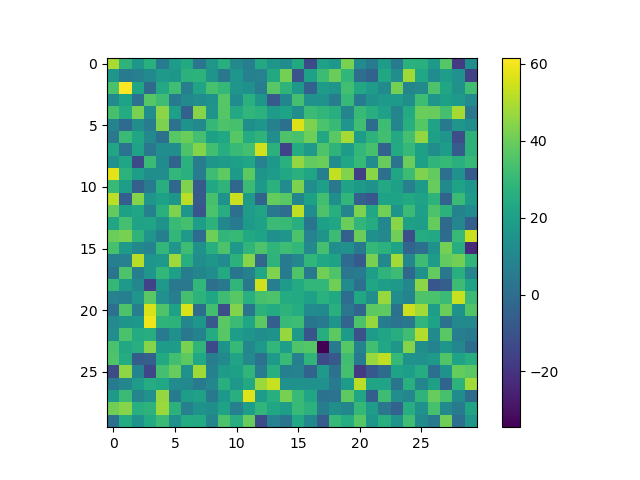

In [139]:
randarr = np.random.randn(N,N)*15 + 20
print( np.min(randarr), np.max(randarr), np.mean(randarr) )
plt.figure()
plt.imshow(randarr)
plt.colorbar()

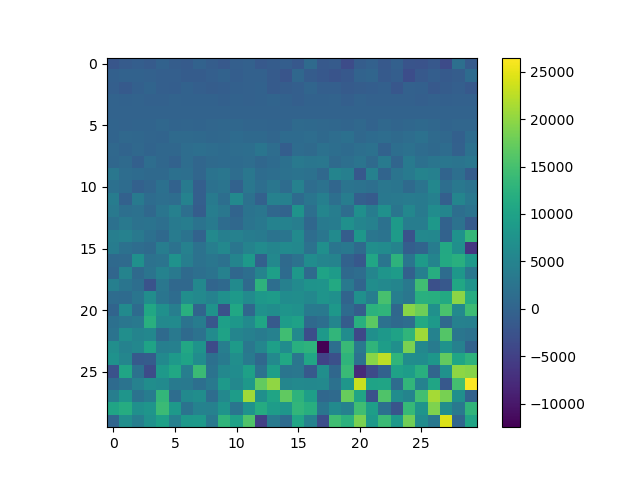

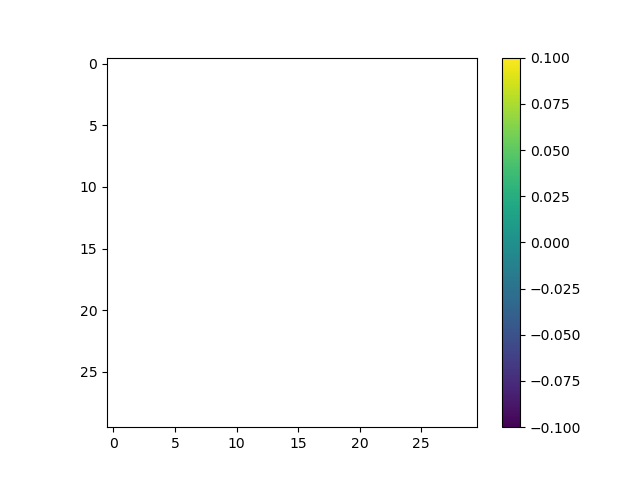

In [149]:
# kladd
N = 30
x = np.ones((N,N))
x *= np.linspace(1,N,N)-5
x = x.T
x *= np.linspace(1,N,N)*0.5 + 10
x1 = x * randarr

plt.figure()
plt.imshow(x1)
plt.colorbar()

error = ((np.abs( x1*np.mean( np.abs(x/x1) ) ) - np.abs(x))) / (np.abs(x))
plt.figure()
plt.imshow(error)
plt.colorbar()

(115,)


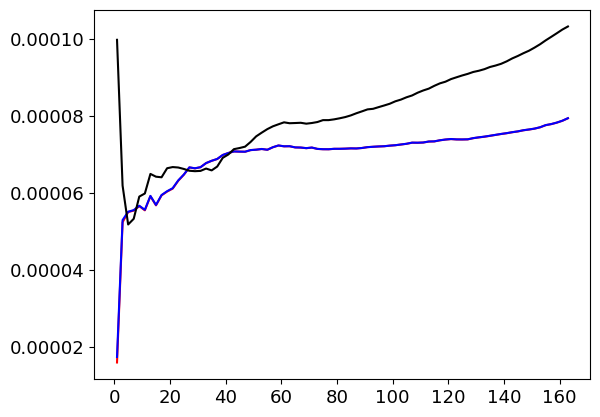

In [130]:
# Plot how the mean abs phase_error changes with object shape size 
N = np.linspace(0, 114, 115)
print(N.shape)
mean_offline = N.copy()
mean_realtime = N.copy()
mean_recons = N.copy()
shsize = N.copy()
for n in N:
    n=int(n)
    # print(f'\n{n}')
    # print(f'offline,  mean phase error: {np.mean(np.abs(phase_error01[n:-n, n:-n])):.10f}, {np.std(np.abs(phase_error01[n:-n, n:-n])):.10f}')
    # print(f'realtime, mean phase error: {np.mean(np.abs(phase_error02[n:-n, n:-n])):.10f}, {np.std(np.abs(phase_error02[n:-n, n:-n])):.10f}')
    # print(f'recons,   mean phase error: {np.mean(np.abs(phase_error03[n:-n, n:-n])):.10f}, {np.std(np.abs(phase_error03[n:-n, n:-n])):.10f}')
    mean_offline[n] = np.mean(np.abs(phase_error01[n:-n, n:-n]))
    mean_realtime[n] = np.mean(np.abs(phase_error02[n:-n, n:-n]))
    mean_recons[n] = np.mean(np.abs(phase_error03[n:-n, n:-n]))
    shsize[n] = phase_error01[n:-n, n:-n].shape[0]

plt.figure()
plt.plot(shsize, mean_offline, 'r')
plt.plot(shsize, mean_realtime, 'b')
plt.plot(shsize, mean_recons*70, 'k')

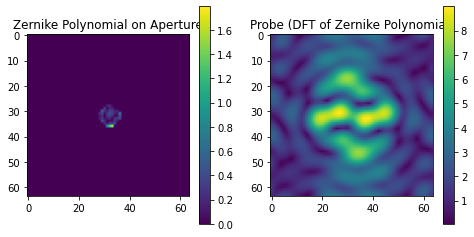

In [6]:
# Create probes as in reference [2], generated by ChatGPT from the text in the paper.
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift
import math

def radial_zernike_polynomial(n, m, rho):
    """Compute the radial Zernike polynomial R_n^m."""
    Rnm = np.zeros_like(rho)
    for s in range((n - abs(m)) // 2 + 1):
        coeff = (-1)**s * math.factorial(n - s) / (
            math.factorial(s) * math.factorial((n + abs(m))//2 - s) * math.factorial((n - abs(m))//2 - s)
        )
        Rnm += coeff * rho**(n - 2 * s)
    return Rnm

def zernike_polynomial(n, m, rho, theta):
    """Evaluate the Zernike polynomial Z_n^m on a circular aperture."""
    Rnm = radial_zernike_polynomial(n, m, rho)
    if m >= 0:
        return Rnm * np.cos(m * theta)
    else:
        return Rnm * np.sin(-m * theta)

def sample_zernike_coefficients(max_degree=4, stddev=0.2):
    """Sample random coefficients for Zernike polynomials up to max_degree."""
    zernike_coefficients = {}

    for n in range(max_degree + 1):
        for m in range(-n, n + 1, 2):
            if n == 0 and m == 0:  # Piston term Z_0^0
                zernike_coefficients[(n, m)] = 0.0
            else:
                zernike_coefficients[(n, m)] = np.random.normal(0.0, stddev)
    
    return zernike_coefficients

def create_circular_mask(shape, radius_fraction):
    """Create a circular mask with radius_fraction in the given shape."""
    rows, cols = shape
    center = (rows // 2, cols // 2)
    Y, X = np.ogrid[:rows, :cols]
    distance = np.sqrt((X - center[1])**2 + (Y - center[0])**2)
    radius = radius_fraction * (rows // 2)
    mask = distance <= radius
    return mask

def evaluate_zernike_on_aperture(coeffs, aperture_radius, grid_size=(64, 64)):
    """Evaluate the Zernike polynomial on a circular aperture within a grid."""
    # Create grid
    y, x = np.linspace(-1, 1, grid_size[0]), np.linspace(-1, 1, grid_size[1])
    X, Y = np.meshgrid(x, y)
    
    # Convert Cartesian to polar coordinates
    rho = np.sqrt(X**2 + Y**2) / aperture_radius  # normalize by aperture radius
    theta = np.arctan2(Y, X)
    
    # Create a mask to limit evaluation to within the aperture
    mask = create_circular_mask(grid_size, aperture_radius)
    
    # Evaluate Zernike polynomials and apply coefficients
    zernike_sum = np.zeros(grid_size, dtype=np.complex64)
    for (n, m), coeff in coeffs.items():
        Znm = zernike_polynomial(n, m, rho, theta)
        zernike_sum += coeff * Znm * mask  # Only evaluate within the mask
    
    return zernike_sum

def calculate_probe(zernike_array):
    """Calculate the probe by taking the DFT of the Zernike polynomial array."""
    dft_result = fftshift(fft2(zernike_array))
    return dft_result

# Main function
def main():
    # Parameters
    max_degree = 4
    stddev = 0.2
    grid_size = (64, 64)
    
    # Sample Zernike coefficients
    zernike_coeffs = sample_zernike_coefficients(max_degree=max_degree, stddev=stddev)
    
    # Random aperture radius between 1/7 and 1/11
    aperture_radius = np.random.uniform(1/11, 1/7)
    
    # Evaluate Zernike polynomials on the aperture
    zernike_array = evaluate_zernike_on_aperture(zernike_coeffs, aperture_radius, grid_size=grid_size)
    
    # Calculate the probe by taking the DFT
    probe = calculate_probe(zernike_array)
    
    # Plot the magnitude of the probe
    plt.figure(figsize=(8, 4))
    
    plt.subplot(1, 2, 1)
    plt.title('Zernike Polynomial on Aperture')
    plt.imshow(np.abs(zernike_array), cmap='viridis')
    plt.colorbar()
    
    plt.subplot(1, 2, 2)
    plt.title('Probe (DFT of Zernike Polynomial)')
    plt.imshow(np.abs(probe), cmap='viridis')
    plt.colorbar()
    
    plt.show()



main()